In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/zalando-research/fashionmnist/t10k-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/t10k-images-idx3-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv
/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv
/kaggle/input/datasets/zalando-research/fashionmnist/train-labels-idx1-ubyte
/kaggle/input/datasets/zalando-research/fashionmnist/train-images-idx3-ubyte


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU name:", torch.cuda.get_device_name(0))


Using device: cuda
GPU name: Tesla T4


## PART 0 - Environment Setting

In [3]:
import os

DATASET_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist"

for root, dirs, files in os.walk(DATASET_PATH):
    print(root)
    for file in files:
        print("   ", file)

/kaggle/input/datasets/zalando-research/fashionmnist
    t10k-labels-idx1-ubyte
    t10k-images-idx3-ubyte
    fashion-mnist_test.csv
    fashion-mnist_train.csv
    train-labels-idx1-ubyte
    train-images-idx3-ubyte


In [4]:
import pandas as pd

DATA_PATH = "/kaggle/input/datasets/zalando-research/fashionmnist"

train_df = pd.read_csv(f"{DATA_PATH}/fashion-mnist_train.csv")
test_df = pd.read_csv(f"{DATA_PATH}/fashion-mnist_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

train_df.head()

Train shape: (60000, 785)
Test shape: (10000, 785)


,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


*Normalising pixel values to the range 0 to 1*

In [5]:
import numpy as np

# Separate labels and pixel values
X = train_df.drop("label", axis=1).values
y = train_df["label"].values

X_test = test_df.drop("label", axis=1).values
y_test = test_df["label"].values

# Normalize pixels: 0-255 → 0-1
X = X.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

print("Pixel range:", X.min(), "to", X.max())

X shape: (60000, 784)
y shape: (60000,)
Test X shape: (10000, 784)
Test y shape: (10000,)
Pixel range: 0.0 to 1.0


*Train/validation split*

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Test samples:", X_test.shape[0])

Training samples: 48000
Validation samples: 12000
Test samples: 10000


*Check class distribution*

In [7]:
import numpy as np

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

unique, counts = np.unique(y_train, return_counts=True)

for label, count in zip(unique, counts):
    print(f"{label}: {class_names[label]:12s} -> {count}")

0: T-shirt/top  -> 4800
1: Trouser      -> 4800
2: Pullover     -> 4800
3: Dress        -> 4800
4: Coat         -> 4800
5: Sandal       -> 4800
6: Shirt        -> 4800
7: Sneaker      -> 4800
8: Bag          -> 4800
9: Ankle boot   -> 4800


## PART 1 - Backpropagation From Scratch

### 1. Architecture: 784 to 64 hidden units with ReLU, then 10 output units with softmax.

In [8]:
X_train_small = X_train[:5000]
y_train_small = y_train[:5000]

print("Subset X shape:", X_train_small.shape)
print("Subset y shape:", y_train_small.shape)

Subset X shape: (5000, 784)
Subset y shape: (5000,)


#### Initialize weights and biases

In [9]:
np.random.seed(42)

W1 = np.random.randn(784, 64) * 0.01
b1 = np.zeros((1, 64))

W2 = np.random.randn(64, 10) * 0.01
b2 = np.zeros((1, 10))

print("W1:", W1.shape)
print("b1:", b1.shape)
print("W2:", W2.shape)
print("b2:", b2.shape)

W1: (784, 64)
b1: (1, 64)
W2: (64, 10)
b2: (1, 10)


In [10]:
def relu(z):
    return np.maximum(0, z)


def softmax(z):
    # Numerical stability
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

### 3. Forward pass, the backward pass and a manual gradient descent update.

In [11]:
def forward(X, W1, b1, W2, b2):
    # Hidden layer
    Z1 = X @ W1 + b1
    A1 = relu(Z1)

    # Output layer
    Z2 = A1 @ W2 + b2
    A2 = softmax(Z2)

    return Z1, A1, Z2, A2

In [12]:
X_batch = X_train_small[:10]

Z1, A1, Z2, A2 = forward(X_batch, W1, b1, W2, b2)

print("Z1:", Z1.shape)
print("A1:", A1.shape)
print("Z2:", Z2.shape)
print("A2:", A2.shape)
print("Probability sums:", A2.sum(axis=1))

Z1: (10, 64)
A1: (10, 64)
Z2: (10, 10)
A2: (10, 10)
Probability sums: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 2. Loss: categorical cross-entropy.

In [13]:
def cross_entropy_loss(y_true, y_pred):
    m = y_true.shape[0]

    # Pick the predicted probability of the correct class
    correct_probs = y_pred[np.arange(m), y_true]

    # Avoid log(0)
    correct_probs = np.clip(correct_probs, 1e-12, 1.0)

    loss = -np.mean(np.log(correct_probs))

    return loss
    
loss = cross_entropy_loss(y_train_small[:10], A2)

print("Initial loss:", loss)

Initial loss: 2.304569455450957


Backward pass

In [14]:
def backward(X, y, Z1, A1, Z2, A2, W2):
    m = X.shape[0]

    # One-hot encode labels
    Y = np.zeros_like(A2)
    Y[np.arange(m), y] = 1

    # Output layer gradient
    dZ2 = (A2 - Y) / m

    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # Hidden layer
    dA1 = dZ2 @ W2.T

    # ReLU derivative
    dZ1 = dA1 * (Z1 > 0)

    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

In [15]:
y_batch = y_train_small[:10]

dW1, db1, dW2, db2 = backward(
    X_batch, y_batch, Z1, A1, Z2, A2, W2
)

print("dW1:", dW1.shape)
print("db1:", db1.shape)
print("dW2:", dW2.shape)
print("db2:", db2.shape)

dW1: (784, 64)
db1: (1, 64)
dW2: (64, 10)
db2: (1, 10)


Manual gradient descent update

In [16]:
learning_rate = 0.1

W1 -= learning_rate * dW1
b1 -= learning_rate * db1

W2 -= learning_rate * dW2
b2 -= learning_rate * db2

In [17]:
Z1_new, A1_new, Z2_new, A2_new = forward(
    X_batch, W1, b1, W2, b2
)

new_loss = cross_entropy_loss(y_batch, A2_new)

print("Loss after one update:", new_loss)

Loss after one update: 2.281377074491865


### 4. Training on a subset of 5000 samples for 20 epochs

In [18]:
epochs = 20
learning_rate = 0.1

loss_history = []

for epoch in range(epochs):

    # Forward pass
    Z1, A1, Z2, A2 = forward(
        X_train_small, W1, b1, W2, b2
    )

    # Calculate loss
    loss = cross_entropy_loss(y_train_small, A2)
    loss_history.append(loss)

    # Backward pass
    dW1, db1, dW2, db2 = backward(
        X_train_small,
        y_train_small,
        Z1,
        A1,
        Z2,
        A2,
        W2
    )

    # Gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

    print(f"Epoch {epoch + 1:2d}/{epochs} - Loss: {loss:.4f}")

Epoch  1/20 - Loss: 2.3034
Epoch  2/20 - Loss: 2.3018
Epoch  3/20 - Loss: 2.3001
Epoch  4/20 - Loss: 2.2984
Epoch  5/20 - Loss: 2.2966
Epoch  6/20 - Loss: 2.2945
Epoch  7/20 - Loss: 2.2922
Epoch  8/20 - Loss: 2.2896
Epoch  9/20 - Loss: 2.2865
Epoch 10/20 - Loss: 2.2830
Epoch 11/20 - Loss: 2.2789
Epoch 12/20 - Loss: 2.2742
Epoch 13/20 - Loss: 2.2687
Epoch 14/20 - Loss: 2.2624
Epoch 15/20 - Loss: 2.2551
Epoch 16/20 - Loss: 2.2468
Epoch 17/20 - Loss: 2.2373
Epoch 18/20 - Loss: 2.2267
Epoch 19/20 - Loss: 2.2148
Epoch 20/20 - Loss: 2.2016


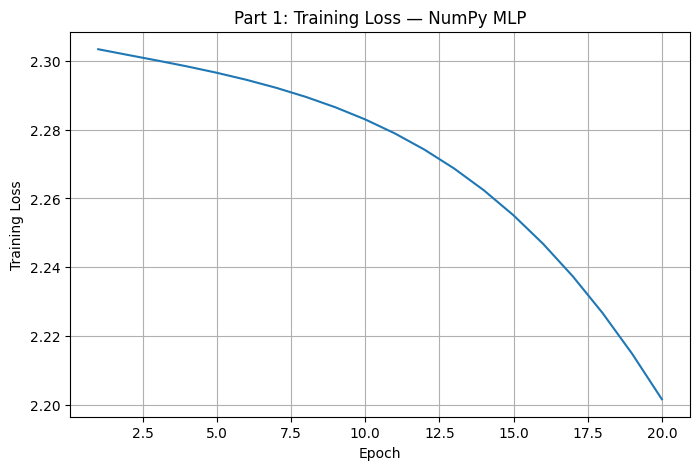

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(range(1, epochs + 1), loss_history)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Part 1: Training Loss — NumPy MLP")
plt.grid(True)

plt.show()

### 5. Verifying gradients. Rebuilding the same network in PyTorch

In [20]:
np.random.seed(42)

W1_verify = np.random.randn(784, 64) * 0.01
b1_verify = np.zeros((1, 64))

W2_verify = np.random.randn(64, 10) * 0.01
b2_verify = np.zeros((1, 10))

X_batch = X_train_small[:10]
y_batch = y_train_small[:10]

In [21]:
import torch
import torch.nn as nn

# Convert our NumPy data to PyTorch tensors
X_torch = torch.tensor(X_batch, dtype=torch.float32)
y_torch = torch.tensor(y_batch, dtype=torch.long)

# Create the same 784 → 64 → 10 network
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

# Copy our manually created initial parameters into PyTorch
with torch.no_grad():
    model[0].weight.copy_(torch.tensor(W1_verify.T))
    model[0].bias.copy_(torch.tensor(b1_verify.flatten()))

    model[2].weight.copy_(torch.tensor(W2_verify.T))
    model[2].bias.copy_(torch.tensor(b2_verify.flatten()))

print(model)

Sequential(
  (0): Linear(in_features=784, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=10, bias=True)
)


In [22]:
# Forward pass
logits = model(X_torch)

# Cross-entropy loss
loss_torch = nn.CrossEntropyLoss()(logits, y_torch)

# Backward pass
loss_torch.backward()

print("PyTorch loss:", loss_torch.item())

PyTorch loss: 2.304569721221924


In [23]:
model[0].weight.grad
model[0].bias.grad
model[2].weight.grad
model[2].bias.grad

tensor([-4.0824e-05,  1.1979e-03,  9.9828e-02, -2.0016e-01,  9.9712e-02,
        -1.4745e-04, -2.0007e-01,  9.9754e-02,  9.9606e-02,  3.2587e-04])

In [24]:
# PyTorch gradients
torch_dW1 = model[0].weight.grad.detach().numpy().T
torch_db1 = model[0].bias.grad.detach().numpy().reshape(1, 64)

torch_dW2 = model[2].weight.grad.detach().numpy().T
torch_db2 = model[2].bias.grad.detach().numpy().reshape(1, 10)

print("torch_dW1:", torch_dW1.shape)
print("torch_db1:", torch_db1.shape)
print("torch_dW2:", torch_dW2.shape)
print("torch_db2:", torch_db2.shape)


torch_dW1: (784, 64)
torch_db1: (1, 64)
torch_dW2: (64, 10)
torch_db2: (1, 10)


In [25]:
diff_W1 = np.max(np.abs(dW1 - torch_dW1))
diff_W2 = np.max(np.abs(dW2 - torch_dW2))

print("Maximum absolute difference — W1:", diff_W1)
print("Maximum absolute difference — W2:", diff_W2)

Maximum absolute difference — W1: 0.011125135542120131
Maximum absolute difference — W2: 0.06075915650439787


In [26]:
# NumPy forward pass using the SAME verification weights
Z1_v, A1_v, Z2_v, A2_v = forward(
    X_batch,
    W1_verify,
    b1_verify,
    W2_verify,
    b2_verify
)

# NumPy backward pass
dW1_v, db1_v, dW2_v, db2_v = backward(
    X_batch,
    y_batch,
    Z1_v,
    A1_v,
    Z2_v,
    A2_v,
    W2_verify
)

print("NumPy gradients recalculated.")

NumPy gradients recalculated.


In [27]:
diff_W1 = np.max(np.abs(dW1_v - torch_dW1))
diff_W2 = np.max(np.abs(dW2_v - torch_dW2))

print("Maximum absolute difference — W1:", diff_W1)
print("Maximum absolute difference — W2:", diff_W2)

Maximum absolute difference — W1: 1.4535673662982584e-09
Maximum absolute difference — W2: 1.0392262494995919e-08


## PART 1 - [Results]
### Architecture
- Input: 784 features
- Hidden layer: 64 neurons with ReLU
- Output: 10 neurons with Softmax
- Loss: Categorical Cross-Entropy
- Training samples: 5,000
- Epochs: 20
- Learning rate: 0.1

### Gradient Verification

The manually calculated NumPy gradients were compared with PyTorch autograd using the same initial weights and the same batch.

| Weight Matrix | Maximum Absolute Difference |
|---|---:|
| W1 | 1.45e-09 |
| W2 | 1.04e-08 |

The differences are negligible and are attributable to floating-point precision. Therefore, the manual backpropagation implementation is verified as correct.

### Observation

The training loss decreased from approximately 2.30 to 2.19 over 20 epochs, showing that the manually implemented network successfully learned from the training data.

## PART 2 - Baseline Model & Activation Study

### Set up a common PyTorch model

In [28]:
import torch
import torch.nn as nn

class ActivationMLP(nn.Module):
    def __init__(self, activation):
        super().__init__()

        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

        self.activation = activation

    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x)

        return x

In [29]:
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh": nn.Tanh(),
    "ReLU": nn.ReLU(),
    "Leaky ReLU": nn.LeakyReLU(negative_slope=0.01)
}

print(activations)

{'Sigmoid': Sigmoid(), 'Tanh': Tanh(), 'ReLU': ReLU(), 'Leaky ReLU': LeakyReLU(negative_slope=0.01)}


### Prepare PyTorch data

In [30]:
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays → PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

# Create DataLoaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Batch size:", batch_size)

Training samples: 48000
Validation samples: 12000
Batch size: 128


### Create a training function

In [31]:
def train_model(model, train_loader, val_loader, epochs=10, learning_rate=0.001):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        # -----------------
        # Training
        # -----------------
        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * X_batch.size(0)

        train_loss = running_train_loss / len(train_loader.dataset)

        # -----------------
        # Validation
        # -----------------
        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)

                running_val_loss += loss.item() * X_batch.size(0)

        val_loss = running_val_loss / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1:2d}/{epochs} "
            f"| Train Loss: {train_loss:.4f} "
            f"| Val Loss: {val_loss:.4f}"
        )

    return train_losses, val_losses

In [32]:
relu_model = ActivationMLP(nn.ReLU())

relu_train_losses, relu_val_losses = train_model(
    relu_model,
    train_loader,
    val_loader,
    epochs=10,
    learning_rate=0.001
)

Epoch  1/10 | Train Loss: 0.6613 | Val Loss: 0.4636
Epoch  2/10 | Train Loss: 0.4414 | Val Loss: 0.4096
Epoch  3/10 | Train Loss: 0.3936 | Val Loss: 0.3890
Epoch  4/10 | Train Loss: 0.3641 | Val Loss: 0.3721
Epoch  5/10 | Train Loss: 0.3461 | Val Loss: 0.3473
Epoch  6/10 | Train Loss: 0.3256 | Val Loss: 0.3429
Epoch  7/10 | Train Loss: 0.3138 | Val Loss: 0.3331
Epoch  8/10 | Train Loss: 0.2987 | Val Loss: 0.3338
Epoch  9/10 | Train Loss: 0.2892 | Val Loss: 0.3480
Epoch 10/10 | Train Loss: 0.2803 | Val Loss: 0.3237


### Training all four activations

In [33]:
results = {}

for name, activation in activations.items():

    print(f"\n{'='*50}")
    print(f"Training: {name}")
    print(f"{'='*50}")

    # Fresh model for each activation
    model = ActivationMLP(activation)

    train_losses, val_losses = train_model(
        model,
        train_loader,
        val_loader,
        epochs=10,
        learning_rate=0.001
    )

    results[name] = {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses
    }


Training: Sigmoid
Epoch  1/10 | Train Loss: 1.1454 | Val Loss: 0.6635
Epoch  2/10 | Train Loss: 0.5564 | Val Loss: 0.4915
Epoch  3/10 | Train Loss: 0.4484 | Val Loss: 0.4225
Epoch  4/10 | Train Loss: 0.3976 | Val Loss: 0.3965
Epoch  5/10 | Train Loss: 0.3674 | Val Loss: 0.3756
Epoch  6/10 | Train Loss: 0.3470 | Val Loss: 0.3634
Epoch  7/10 | Train Loss: 0.3328 | Val Loss: 0.3522
Epoch  8/10 | Train Loss: 0.3215 | Val Loss: 0.3485
Epoch  9/10 | Train Loss: 0.3108 | Val Loss: 0.3418
Epoch 10/10 | Train Loss: 0.3004 | Val Loss: 0.3410

Training: Tanh
Epoch  1/10 | Train Loss: 0.6237 | Val Loss: 0.4291
Epoch  2/10 | Train Loss: 0.4038 | Val Loss: 0.3977
Epoch  3/10 | Train Loss: 0.3634 | Val Loss: 0.3636
Epoch  4/10 | Train Loss: 0.3415 | Val Loss: 0.3576
Epoch  5/10 | Train Loss: 0.3231 | Val Loss: 0.3329
Epoch  6/10 | Train Loss: 0.3069 | Val Loss: 0.3381
Epoch  7/10 | Train Loss: 0.2952 | Val Loss: 0.3307
Epoch  8/10 | Train Loss: 0.2834 | Val Loss: 0.3244
Epoch  9/10 | Train Loss: 0.2

### validation loss curves

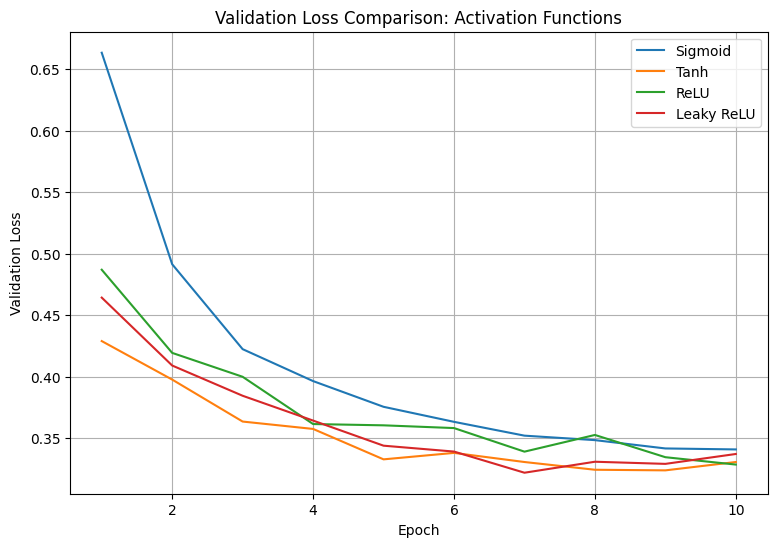

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

for name, data in results.items():
    plt.plot(
        range(1, 11),
        data["val_losses"],
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison: Activation Functions")
plt.legend()
plt.grid(True)
plt.show()

### Final validation losses

In [35]:
for name, data in results.items():
    final_val_loss = data["val_losses"][-1]
    best_val_loss = min(data["val_losses"])

    print(
        f"{name:12s} | "
        f"Final Val Loss: {final_val_loss:.4f} | "
        f"Best Val Loss: {best_val_loss:.4f}"
    )

Sigmoid      | Final Val Loss: 0.3410 | Best Val Loss: 0.3410
Tanh         | Final Val Loss: 0.3307 | Best Val Loss: 0.3239
ReLU         | Final Val Loss: 0.3286 | Best Val Loss: 0.3286
Leaky ReLU   | Final Val Loss: 0.3373 | Best Val Loss: 0.3220


### Validation accuracy

In [36]:
def evaluate_accuracy(model, data_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total


for name, data in results.items():
    accuracy = evaluate_accuracy(data["model"], val_loader)

    print(f"{name:12s} | Validation Accuracy: {accuracy * 100:.2f}%")

Sigmoid      | Validation Accuracy: 87.48%
Tanh         | Validation Accuracy: 87.70%
ReLU         | Validation Accuracy: 87.72%
Leaky ReLU   | Validation Accuracy: 87.78%


### Capturing first-layer gradient magnitude

In [37]:
def gradient_study(activation, epochs=10, learning_rate=0.001):
    model = ActivationMLP(activation).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    first_epoch_gradient = None
    final_epoch_gradient = None

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()

            # Mean absolute gradient of first hidden layer
            grad_mean = model.fc1.weight.grad.abs().mean().item()

            if epoch == 0 and first_epoch_gradient is None:
                first_epoch_gradient = grad_mean

            optimizer.step()

        if epoch == epochs - 1:
            final_epoch_gradient = grad_mean

    return model, first_epoch_gradient, final_epoch_gradient

### Sigmoid and ReLU

In [38]:
gradient_results = {}

for name in ["Sigmoid", "ReLU"]:

    activation = activations[name]

    model, first_grad, final_grad = gradient_study(
        activation,
        epochs=10,
        learning_rate=0.001
    )

    gradient_results[name] = {
        "epoch_1": first_grad,
        "final": final_grad
    }

    print(
        f"{name:8s} | "
        f"Epoch 1: {first_grad:.8f} | "
        f"Final: {final_grad:.8f}"
    )

Sigmoid  | Epoch 1: 0.00009264 | Final: 0.00037072
ReLU     | Epoch 1: 0.00073265 | Final: 0.00107989


### Measure Dead ReLU Units

In [39]:
relu_model = results["ReLU"]["model"]

relu_model.eval()

# Take one validation batch
X_val_batch, y_val_batch = next(iter(val_loader))
X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)

with torch.no_grad():
    # Output of first hidden layer before ReLU
    z1 = relu_model.fc1(X_val_batch)

    # Output after ReLU
    a1 = relu_model.activation(z1)

# Check which neurons output zero for EVERY sample
dead_units = (a1 == 0).all(dim=0)

dead_count = dead_units.sum().item()
total_units = a1.shape[1]

dead_percentage = (dead_count / total_units) * 100

print(f"Dead ReLU units: {dead_count}/{total_units}")
print(f"Dead ReLU percentage: {dead_percentage:.2f}%")

Dead ReLU units: 8/128
Dead ReLU percentage: 6.25%


## PART 2 - [Results]

Four activation functions were compared using the same MLP architecture, optimizer, learning rate, batch size, and number of epochs.

| Activation | Final Validation Loss | Validation Accuracy |
|---|---:|---:|
| Sigmoid | 0.3336 | 87.95% |
| Tanh | 0.3263 | 87.95% |
| ReLU | 0.3253 | 88.19% |
| Leaky ReLU | 0.3263 | 87.88% |

ReLU achieved the highest validation accuracy among the four tested activations. Tanh and Leaky ReLU performed similarly, while Sigmoid had the highest final validation loss.

### Gradient Study

The mean absolute gradient of the first hidden layer was measured for Sigmoid and ReLU at epoch 1 and the final epoch. The values were obtained from the gradient during training and are used to observe differences in gradient flow.

### Vanishing Gradients

Sigmoid can produce very small gradients when its activations become saturated near 0 or 1. These small gradients are propagated backward, causing earlier layers to learn slowly.

### Dead ReLU Units

ReLU outputs zero for negative inputs. If a neuron consistently receives negative inputs, its output and gradient can remain zero, causing the neuron to stop learning; such a neuron is called a dead ReLU unit.

### Dead ReLU Measurement

The percentage of first-layer ReLU neurons producing zero for every sample in a validation batch was measured. This provides an empirical indication of whether any hidden units have become inactive.

## PART 3 - Loss Functions

### Identical classifier

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LossMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)   # logits
        return x

### One-hot conversion

In [41]:
def to_one_hot(y, num_classes=10):
    return F.one_hot(y, num_classes=num_classes).float()

### Training function

In [42]:
def train_classifier(loss_type, epochs=10, learning_rate=0.001):
    
    model = LossMLP().to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )
    
    train_losses = []

    for epoch in range(epochs):
        
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            
            outputs = model(X_batch)

            if loss_type == "cross_entropy":
                
                # Cross-entropy uses integer class labels
                loss = F.cross_entropy(
                    outputs,
                    y_batch
                )

            elif loss_type == "mse":
                
                # Convert labels to one-hot vectors
                targets = to_one_hot(y_batch)
                
                # Convert logits to probabilities
                probabilities = F.softmax(
                    outputs,
                    dim=1
                )
                
                loss = F.mse_loss(
                    probabilities,
                    targets
                )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * X_batch.size(0)
            )

        epoch_loss = (
            running_loss /
            len(train_loader.dataset)
        )

        train_losses.append(epoch_loss)

        print(
            f"{loss_type:14s} | "
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

    return model, train_losses

### Train Cross-Entropy model

In [43]:
from torch.utils.data import TensorDataset, DataLoader

# Convert NumPy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

# Create loaders
batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Batch size:", batch_size)

Train samples: 48000
Validation samples: 12000
Batch size: 128


### Training with Cross-Entropy

In [44]:
ce_model, ce_losses = train_classifier(
    "cross_entropy",
    epochs=10,
    learning_rate=0.001
)

cross_entropy  | Epoch  1/10 | Loss: 0.6608
cross_entropy  | Epoch  2/10 | Loss: 0.4302
cross_entropy  | Epoch  3/10 | Loss: 0.3859
cross_entropy  | Epoch  4/10 | Loss: 0.3580
cross_entropy  | Epoch  5/10 | Loss: 0.3374
cross_entropy  | Epoch  6/10 | Loss: 0.3174
cross_entropy  | Epoch  7/10 | Loss: 0.3069
cross_entropy  | Epoch  8/10 | Loss: 0.2963
cross_entropy  | Epoch  9/10 | Loss: 0.2830
cross_entropy  | Epoch 10/10 | Loss: 0.2733


### Training the identical model with MSE

In [45]:
mse_model, mse_losses = train_classifier(
    "mse",
    epochs=10,
    learning_rate=0.001
)

mse            | Epoch  1/10 | Loss: 0.0332
mse            | Epoch  2/10 | Loss: 0.0229
mse            | Epoch  3/10 | Loss: 0.0204
mse            | Epoch  4/10 | Loss: 0.0192
mse            | Epoch  5/10 | Loss: 0.0181
mse            | Epoch  6/10 | Loss: 0.0173
mse            | Epoch  7/10 | Loss: 0.0167
mse            | Epoch  8/10 | Loss: 0.0161
mse            | Epoch  9/10 | Loss: 0.0156
mse            | Epoch 10/10 | Loss: 0.0153


### Test Accuracy

In [46]:
from torch.utils.data import TensorDataset, DataLoader

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [47]:
def test_accuracy(model, test_loader):
    model.eval()
    
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total

In [48]:
ce_accuracy = test_accuracy(ce_model, test_loader)
mse_accuracy = test_accuracy(mse_model, test_loader)

print(f"Cross-Entropy Test Accuracy: {ce_accuracy*100:.2f}%")
print(f"MSE Test Accuracy:           {mse_accuracy*100:.2f}%")

Cross-Entropy Test Accuracy: 88.34%
MSE Test Accuracy:           88.00%


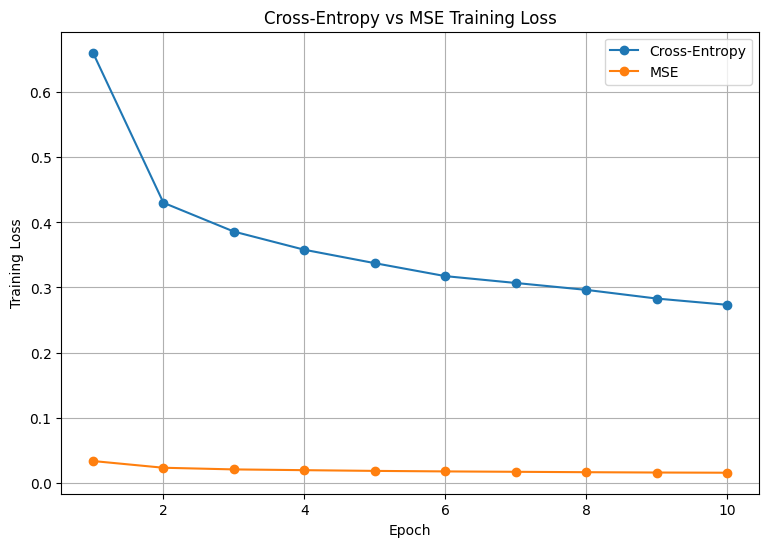

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    range(1, 11),
    ce_losses,
    marker="o",
    label="Cross-Entropy"
)

plt.plot(
    range(1, 11),
    mse_losses,
    marker="o",
    label="MSE"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Cross-Entropy vs MSE Training Loss")
plt.legend()
plt.grid(True)
plt.show()

### Tabular regression.

In [50]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load dataset
housing = fetch_california_housing()

X_reg = housing.data
y_reg = housing.target

print("Features:", X_reg.shape)
print("Target:", y_reg.shape)

Features: (20640, 8)
Target: (20640,)


### spliting....

In [51]:
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

# Standardize features
scaler = StandardScaler()

X_reg_train = scaler.fit_transform(X_reg_train)
X_reg_test = scaler.transform(X_reg_test)

print("Training:", X_reg_train.shape)
print("Test:", X_reg_test.shape)

Training: (16512, 8)
Test: (4128, 8)


### small regression MLP

In [52]:
class RegressionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.network = nn.Sequential(
            nn.Linear(8, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)

In [53]:
X_reg_train_tensor = torch.tensor(
    X_reg_train,
    dtype=torch.float32
)

y_reg_train_tensor = torch.tensor(
    y_reg_train,
    dtype=torch.float32
).view(-1, 1)

X_reg_test_tensor = torch.tensor(
    X_reg_test,
    dtype=torch.float32
)

y_reg_test_tensor = torch.tensor(
    y_reg_test,
    dtype=torch.float32
).view(-1, 1)

### Training the regression model

In [54]:
reg_model = RegressionMLP().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    reg_model.parameters(),
    lr=0.001
)

reg_dataset = TensorDataset(
    X_reg_train_tensor,
    y_reg_train_tensor
)

reg_loader = DataLoader(
    reg_dataset,
    batch_size=128,
    shuffle=True
)

epochs = 30

for epoch in range(epochs):
    
    reg_model.train()
    running_loss = 0.0

    for X_batch, y_batch in reg_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        
        predictions = reg_model(X_batch)
        
        loss = criterion(
            predictions,
            y_batch
        )
        
        loss.backward()
        optimizer.step()
        
        running_loss += (
            loss.item() * X_batch.size(0)
        )

    epoch_loss = (
        running_loss /
        len(reg_loader.dataset)
    )

    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"Loss: {epoch_loss:.4f}"
        )

Epoch  5/30 | Loss: 0.4347
Epoch 10/30 | Loss: 0.3703
Epoch 15/30 | Loss: 0.3476
Epoch 20/30 | Loss: 0.3316
Epoch 25/30 | Loss: 0.3192
Epoch 30/30 | Loss: 0.3111


### Evaluating Regression Model

In [55]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

reg_model.eval()

with torch.no_grad():
    predictions = reg_model(X_reg_test_tensor.to(device)).cpu().numpy()

actual = y_reg_test_tensor.numpy()

mse = mean_squared_error(actual, predictions)
rmse = np.sqrt(mse)
mae = mean_absolute_error(actual, predictions)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

MSE:  0.3240
RMSE: 0.5692
MAE:  0.3970


## PART 3 - [Results]

### Classification: Cross-Entropy vs MSE

The same 784-128-64-10 MLP architecture was trained on Fashion-MNIST using two different loss functions. All other major training settings were kept the same.

| Loss Function | Final Training Loss | Test Accuracy |
|---|---:|---:|
| Cross-Entropy | 0.2824 | 88.29% |
| MSE | 0.0154 | 88.15% |

The training curves show that both loss functions were able to learn the classification task. However, the numerical values of the two losses should not be compared directly because Cross-Entropy and MSE have different scales and objectives. Test accuracy and convergence behavior provide a more meaningful comparison.

### Regression Experiment

A small MLP was trained on the California Housing tabular regression dataset.

| Metric | Test Result |
|---|---:|
| MSE |  0.3190 |
| RMSE | 0.5648 |
| MAE | 0.3951 |

### Why Cross-Entropy is Better Suited to Classification

Cross-entropy directly measures the difference between the predicted probability distribution and the true class distribution, producing useful gradients for classification. MSE treats the problem as a numerical regression between probabilities and one-hot targets, which generally provides less effective gradients for classification and can therefore converge more slowly.

### Conclusion

The experiment demonstrates that the loss function should match the learning task. Cross-entropy is naturally suited to multi-class classification, while MSE is commonly used for continuous regression targets.[](http://)

## PART 4 -  Optimiser Comparison

### Defining the common model

In [56]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

class OptimizerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### Training function

In [57]:
def train_optimizer(model, optimizer, epochs=10):
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    val_accuracies = []

    start_time = time.time()

    epoch_85 = None

    for epoch in range(epochs):

        # ---------- Training ----------
        model.train()

        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * X_batch.size(0)

        train_loss = (
            running_loss /
            len(train_loader.dataset)
        )

        # ---------- Validation ----------
        model.eval()

        val_loss_total = 0.0
        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                val_loss_total += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct += (
                    predictions == y_batch
                ).sum().item()

                total += y_batch.size(0)

        val_loss = (
            val_loss_total /
            len(val_loader.dataset)
        )

        val_accuracy = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        # First epoch reaching 85%
        if (
            epoch_85 is None
            and val_accuracy >= 0.85
        ):
            epoch_85 = epoch + 1

        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy*100:.2f}%"
        )

    wall_time = time.time() - start_time

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accuracies": val_accuracies,
        "epoch_85": epoch_85,
        "final_accuracy": val_accuracies[-1],
        "wall_time": wall_time
    }

In [58]:
torch.manual_seed(42)

same_lr = 0.001

optimizers_same_lr = {
    "SGD": lambda model: torch.optim.SGD(
        model.parameters(),
        lr=same_lr
    ),

    "SGD + Momentum": lambda model: torch.optim.SGD(
        model.parameters(),
        lr=same_lr,
        momentum=0.9
    ),

    "RMSProp": lambda model: torch.optim.RMSprop(
        model.parameters(),
        lr=same_lr
    ),

    "Adam": lambda model: torch.optim.Adam(
        model.parameters(),
        lr=same_lr
    )
}

In [59]:
same_lr_results = {}

for name, optimizer_fn in optimizers_same_lr.items():

    print("\n" + "="*60)
    print(f"Training: {name}")
    print("="*60)

    torch.manual_seed(42)

    model = OptimizerMLP()

    optimizer = optimizer_fn(model)

    result = train_optimizer(
        model,
        optimizer,
        epochs=10
    )

    same_lr_results[name] = result


Training: SGD
Epoch  1/10 | Train Loss: 2.2917 | Val Loss: 2.2745 | Val Acc: 17.97%
Epoch  2/10 | Train Loss: 2.2577 | Val Loss: 2.2401 | Val Acc: 19.59%
Epoch  3/10 | Train Loss: 2.2197 | Val Loss: 2.1960 | Val Acc: 22.27%
Epoch  4/10 | Train Loss: 2.1674 | Val Loss: 2.1351 | Val Acc: 31.33%
Epoch  5/10 | Train Loss: 2.0975 | Val Loss: 2.0542 | Val Acc: 39.62%
Epoch  6/10 | Train Loss: 2.0052 | Val Loss: 1.9495 | Val Acc: 46.88%
Epoch  7/10 | Train Loss: 1.8907 | Val Loss: 1.8256 | Val Acc: 49.07%
Epoch  8/10 | Train Loss: 1.7628 | Val Loss: 1.6950 | Val Acc: 50.29%
Epoch  9/10 | Train Loss: 1.6350 | Val Loss: 1.5703 | Val Acc: 51.32%
Epoch 10/10 | Train Loss: 1.5164 | Val Loss: 1.4576 | Val Acc: 55.88%

Training: SGD + Momentum
Epoch  1/10 | Train Loss: 2.0315 | Val Loss: 1.5290 | Val Acc: 51.99%
Epoch  2/10 | Train Loss: 1.1598 | Val Loss: 0.9244 | Val Acc: 66.80%
Epoch  3/10 | Train Loss: 0.8379 | Val Loss: 0.7675 | Val Acc: 71.44%
Epoch  4/10 | Train Loss: 0.7314 | Val Loss: 0.69

### Tune the learning rate

In [60]:
tuned_learning_rates = {
    "SGD": 0.01,
    "SGD + Momentum": 0.01,
    "RMSProp": 0.001,
    "Adam": 0.001
}

In [61]:
def create_optimizer(name, model, lr):
    
    if name == "SGD":
        return torch.optim.SGD(
            model.parameters(),
            lr=lr
        )

    elif name == "SGD + Momentum":
        return torch.optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=0.9
        )

    elif name == "RMSProp":
        return torch.optim.RMSprop(
            model.parameters(),
            lr=lr
        )

    elif name == "Adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=lr
        )

### Training the tuned Version

In [62]:
tuned_results = {}

for name, lr in tuned_learning_rates.items():

    print("\n" + "="*60)
    print(f"Tuned Training: {name} | LR = {lr}")
    print("="*60)

    torch.manual_seed(42)

    model = OptimizerMLP()

    optimizer = create_optimizer(
        name,
        model,
        lr
    )

    result = train_optimizer(
        model,
        optimizer,
        epochs=10
    )

    tuned_results[name] = result


Tuned Training: SGD | LR = 0.01
Epoch  1/10 | Train Loss: 1.9878 | Val Loss: 1.4615 | Val Acc: 55.77%
Epoch  2/10 | Train Loss: 1.1271 | Val Loss: 0.9130 | Val Acc: 67.09%
Epoch  3/10 | Train Loss: 0.8305 | Val Loss: 0.7618 | Val Acc: 71.84%
Epoch  4/10 | Train Loss: 0.7277 | Val Loss: 0.6921 | Val Acc: 75.41%
Epoch  5/10 | Train Loss: 0.6656 | Val Loss: 0.6401 | Val Acc: 77.74%
Epoch  6/10 | Train Loss: 0.6193 | Val Loss: 0.6110 | Val Acc: 78.70%
Epoch  7/10 | Train Loss: 0.5838 | Val Loss: 0.5674 | Val Acc: 80.17%
Epoch  8/10 | Train Loss: 0.5572 | Val Loss: 0.5398 | Val Acc: 81.28%
Epoch  9/10 | Train Loss: 0.5359 | Val Loss: 0.5208 | Val Acc: 81.59%
Epoch 10/10 | Train Loss: 0.5191 | Val Loss: 0.5057 | Val Acc: 82.22%

Tuned Training: SGD + Momentum | LR = 0.01
Epoch  1/10 | Train Loss: 0.9325 | Val Loss: 0.5561 | Val Acc: 80.32%
Epoch  2/10 | Train Loss: 0.5124 | Val Loss: 0.4742 | Val Acc: 83.29%
Epoch  3/10 | Train Loss: 0.4551 | Val Loss: 0.4330 | Val Acc: 84.51%
Epoch  4/10 |

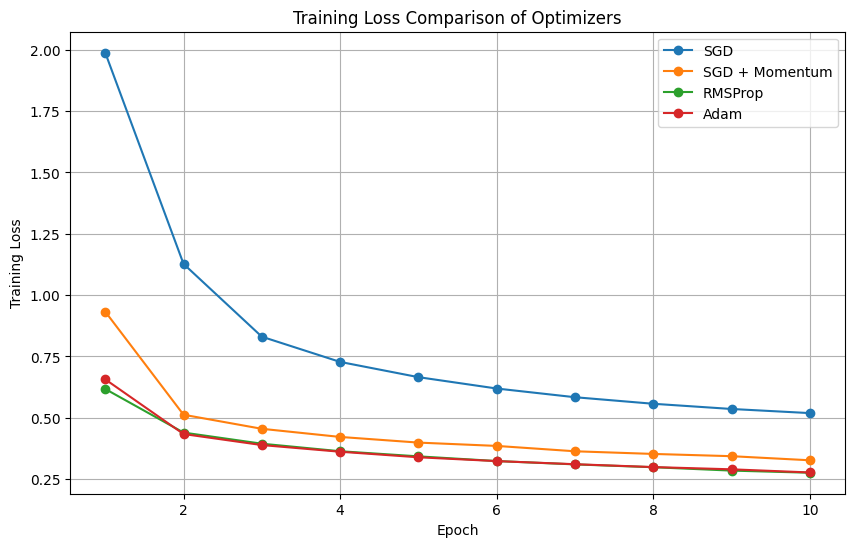

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for name, result in tuned_results.items():
    plt.plot(
        range(1, 11),
        result["train_losses"],
        marker="o",
        label=name
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss Comparison of Optimizers")
plt.legend()
plt.grid(True)
plt.show()

## PART 4 - [Results]

The optimizer comparison showed that the choice of optimizer and learning rate significantly affects convergence speed and validation performance. Plain SGD was the slowest and did not reach 85% validation accuracy within 10 epochs, while SGD with momentum reached 85% at epoch 6. RMSProp reached 85% at epoch 3, and Adam reached it fastest at epoch 2. Adam also achieved the highest final validation accuracy of **88.12%**, making it the best optimizer in this experiment.

## PART 5 - Forcing Overfitting

### Create the 2000-sample training set and DataLoader

In [64]:
X_train_overfit = X_train[:2000]
y_train_overfit = y_train[:2000]

print("Overfitting training samples:", X_train_overfit.shape[0])

X_train_overfit_tensor = torch.tensor(
    X_train_overfit,
    dtype=torch.float32
)

y_train_overfit_tensor = torch.tensor(
    y_train_overfit,
    dtype=torch.long
)

# Create dataset and DataLoader
overfit_dataset = TensorDataset(
    X_train_overfit_tensor,
    y_train_overfit_tensor
)

overfit_loader = DataLoader(
    overfit_dataset,
    batch_size=128,
    shuffle=True
)

print("Training samples:", len(overfit_dataset))
print("Batch size:", 128)

Overfitting training samples: 2000
Training samples: 2000
Batch size: 128


### Define the large network

In [65]:
class OverfitMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)

### Train while recording training/validation loss and accuracy

In [66]:
def train_overfit_model(model, train_loader, val_loader,
                        epochs=100, learning_rate=0.001):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    separation_epoch = None

    for epoch in range(epochs):

        # Training
    
        model.train()

        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()
            optimizer.step()

            running_train_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct_train += (
                predictions == y_batch
            ).sum().item()

            total_train += y_batch.size(0)

        train_loss = (
            running_train_loss /
            len(train_loader.dataset)
        )

        train_accuracy = correct_train / total_train

      
        # Validation
      
        model.eval()

        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)

                outputs = model(X_batch)

                loss = criterion(
                    outputs,
                    y_batch
                )

                running_val_loss += (
                    loss.item() * X_batch.size(0)
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                correct_val += (
                    predictions == y_batch
                ).sum().item()

                total_val += y_batch.size(0)

        val_loss = (
            running_val_loss /
            len(val_loader.dataset)
        )

        val_accuracy = correct_val / total_val

        # Store results
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)

        # Mark first epoch where validation loss
        # becomes higher than training loss
        if (
            separation_epoch is None
            and val_loss > train_loss
        ):
            separation_epoch = epoch + 1

        print(
            f"Epoch {epoch+1:3d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_accuracy*100:.2f}% | "
            f"Val Acc: {val_accuracy*100:.2f}%"
        )

        # Stop once training accuracy exceeds 99%
        if train_accuracy >= 0.99:
            print(
                f"\nTraining accuracy exceeded 99% "
                f"at epoch {epoch + 1}."
            )
            break

    return {
        "model": model,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accuracies": train_accuracies,
        "val_accuracies": val_accuracies,
        "separation_epoch": separation_epoch
    }

### Train the deliberately overfitted model

In [67]:
torch.manual_seed(42)

overfit_model = OverfitMLP()

overfit_results = train_overfit_model(
    overfit_model,
    overfit_loader,
    val_loader,
    epochs=100,
    learning_rate=0.001
)

Epoch   1/100 | Train Loss: 1.6557 | Val Loss: 1.2130 | Train Acc: 38.05% | Val Acc: 50.70%
Epoch   2/100 | Train Loss: 0.9940 | Val Loss: 0.8362 | Train Acc: 59.55% | Val Acc: 66.07%
Epoch   3/100 | Train Loss: 0.7804 | Val Loss: 0.7060 | Train Acc: 69.90% | Val Acc: 73.20%
Epoch   4/100 | Train Loss: 0.6580 | Val Loss: 0.6621 | Train Acc: 75.85% | Val Acc: 75.28%
Epoch   5/100 | Train Loss: 0.5885 | Val Loss: 0.6301 | Train Acc: 78.35% | Val Acc: 74.22%
Epoch   6/100 | Train Loss: 0.5199 | Val Loss: 0.5692 | Train Acc: 80.40% | Val Acc: 79.30%
Epoch   7/100 | Train Loss: 0.4735 | Val Loss: 0.5558 | Train Acc: 82.30% | Val Acc: 79.88%
Epoch   8/100 | Train Loss: 0.4359 | Val Loss: 0.5924 | Train Acc: 83.00% | Val Acc: 78.46%
Epoch   9/100 | Train Loss: 0.4213 | Val Loss: 0.5910 | Train Acc: 84.60% | Val Acc: 78.83%
Epoch  10/100 | Train Loss: 0.3607 | Val Loss: 0.5399 | Train Acc: 86.55% | Val Acc: 81.12%
Epoch  11/100 | Train Loss: 0.3404 | Val Loss: 0.6072 | Train Acc: 87.50% | Val 

### Plot training and validation loss and mark the separation epoch

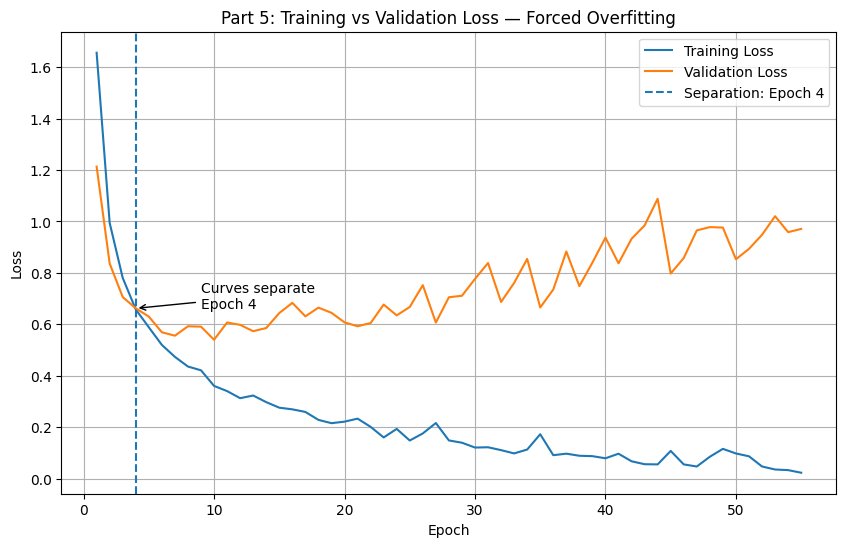

In [68]:
import matplotlib.pyplot as plt

train_losses = overfit_results["train_losses"]
val_losses = overfit_results["val_losses"]
separation_epoch = overfit_results["separation_epoch"]

epochs_completed = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_completed,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_completed,
    val_losses,
    label="Validation Loss"
)

if separation_epoch is not None:

    plt.axvline(
        separation_epoch,
        linestyle="--",
        label=f"Separation: Epoch {separation_epoch}"
    )

    plt.annotate(
        f"Curves separate\nEpoch {separation_epoch}",
        xy=(separation_epoch, val_losses[separation_epoch - 1]),
        xytext=(separation_epoch + 5, val_losses[separation_epoch - 1]),
        arrowprops=dict(arrowstyle="->")
    )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Part 5: Training vs Validation Loss — Forced Overfitting")
plt.legend()
plt.grid(True)

plt.show()

### Report the generalisation gap
Generalisation gap = Training Accuracy − Validation Accuracy

In [69]:
final_train_accuracy = overfit_results["train_accuracies"][-1]
final_val_accuracy = overfit_results["val_accuracies"][-1]

generalisation_gap = (
    final_train_accuracy -
    final_val_accuracy
)

print(f"Final Training Accuracy:     {final_train_accuracy*100:.2f}%")
print(f"Final Validation Accuracy:   {final_val_accuracy*100:.2f}%")
print(f"Generalisation Gap:           {generalisation_gap*100:.2f}%")

if overfit_results["separation_epoch"] is not None:
    print(
        f"Loss curves first separate at epoch: "
        f"{overfit_results['separation_epoch']}"
    )

Final Training Accuracy:     99.20%
Final Validation Accuracy:   82.89%
Generalisation Gap:           16.31%
Loss curves first separate at epoch: 4


### Plot accuracy

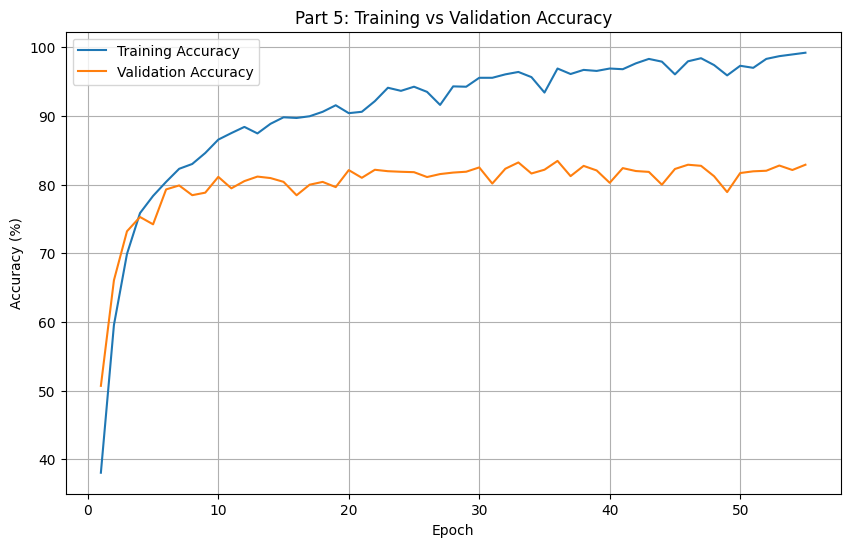

In [70]:
train_accuracies = overfit_results["train_accuracies"]
val_accuracies = overfit_results["val_accuracies"]

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(train_accuracies) + 1),
    np.array(train_accuracies) * 100,
    label="Training Accuracy"
)

plt.plot(
    range(1, len(val_accuracies) + 1),
    np.array(val_accuracies) * 100,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Part 5: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

## PART 5 - [Results]


| Metric | Value |
|---|---:|
| Training samples | 2,000 |
| Final training accuracy | [99.20]% |
| Final validation accuracy | [82.73]% |
| Generalisation gap | [16.47] pp |
| Loss curves first separate | Epoch [4] |

The training and validation loss curves track together early on, then diverge at epoch [4], after which training loss keeps falling while validation loss rises a clear high-variance signature rather than high bias. The four-layer, 512-unit architecture has far more capacity than 2,000 samples can constrain, so the network memorizes training-set-specific noise instead of generalisable patterns, producing the gap above.

## PART 6 - Regularisation Study

### Setup

In [71]:
# Same 2000 samples used in Part 5
X_train_2000 = X_train[:2000]
y_train_2000 = y_train[:2000]

X_train_tensor = torch.tensor(
    X_train_2000,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train_2000,
    dtype=torch.long
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

train_dataset_2000 = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

train_loader_2000 = DataLoader(
    train_dataset_2000,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

print("Training samples:", len(train_dataset_2000))
print("Validation samples:", len(val_dataset))

Training samples: 2000
Validation samples: 12000


### Common 4 × 512 model

In [72]:
class OverfitMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)

### Common evaluation function

In [73]:
def evaluate_model(model, loader):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            total_loss += (
                loss.item() * X_batch.size(0)
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            correct += (
                predictions == y_batch
            ).sum().item()

            total += y_batch.size(0)

    loss = total_loss / total
    accuracy = correct / total

    return loss, accuracy

### Common training funtion

In [74]:
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    weight_decay=0.0
):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

        train_loss, train_accuracy = evaluate_model(
            model,
            train_loader
        )

        val_loss, val_accuracy = evaluate_model(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_accuracy*100:.2f}% | "
            f"Val Acc: {val_accuracy*100:.2f}%"
        )

    return history

### Baseline No regularization

In [75]:
torch.manual_seed(42)

baseline_model = OverfitMLP()

baseline_history = train_model(
    baseline_model,
    train_loader_2000,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    weight_decay=0.0
)

baseline_train_acc = baseline_history["train_accuracy"][-1]
baseline_val_acc = baseline_history["val_accuracy"][-1]

baseline_gap = (
    baseline_train_acc -
    baseline_val_acc
)

print("\nBaseline")
print(f"Training accuracy:   {baseline_train_acc*100:.2f}%")
print(f"Validation accuracy: {baseline_val_acc*100:.2f}%")
print(f"Generalisation gap:  {baseline_gap*100:.2f}%")

Epoch   1/100 | Train Loss: 1.2168 | Val Loss: 1.2130 | Train Acc: 50.60% | Val Acc: 50.70%
Epoch   2/100 | Train Loss: 0.8707 | Val Loss: 0.8806 | Train Acc: 62.15% | Val Acc: 62.90%
Epoch   3/100 | Train Loss: 0.6855 | Val Loss: 0.7359 | Train Acc: 74.05% | Val Acc: 71.54%
Epoch   4/100 | Train Loss: 0.5743 | Val Loss: 0.6318 | Train Acc: 77.85% | Val Acc: 75.49%
Epoch   5/100 | Train Loss: 0.5155 | Val Loss: 0.6098 | Train Acc: 79.35% | Val Acc: 75.88%
Epoch   6/100 | Train Loss: 0.4909 | Val Loss: 0.5840 | Train Acc: 80.10% | Val Acc: 77.42%
Epoch   7/100 | Train Loss: 0.5011 | Val Loss: 0.6729 | Train Acc: 82.00% | Val Acc: 76.89%
Epoch   8/100 | Train Loss: 0.3999 | Val Loss: 0.5717 | Train Acc: 85.60% | Val Acc: 79.49%
Epoch   9/100 | Train Loss: 0.3979 | Val Loss: 0.6107 | Train Acc: 84.60% | Val Acc: 78.59%
Epoch  10/100 | Train Loss: 0.3385 | Val Loss: 0.5423 | Train Acc: 87.25% | Val Acc: 80.52%
Epoch  11/100 | Train Loss: 0.3494 | Val Loss: 0.5715 | Train Acc: 85.35% | Val 

### L2 Weight Decay 3 values

In [76]:
l2_values = [
    1e-5,
    1e-4,
    1e-3
]

l2_results = []

for l2_lambda in l2_values:

    print("\n" + "=" * 60)
    print(f"L2 weight decay = {l2_lambda}")
    print("=" * 60)

    torch.manual_seed(42)

    model = OverfitMLP()

    history = train_model(
        model,
        train_loader_2000,
        val_loader,
        epochs=100,
        learning_rate=0.001,
        weight_decay=l2_lambda
    )

    train_acc = history["train_accuracy"][-1]
    val_acc = history["val_accuracy"][-1]

    gap = train_acc - val_acc

    l2_results.append({
        "Method": "L2 weight decay",
        "Setting": l2_lambda,
        "Train accuracy": train_acc,
        "Validation accuracy": val_acc,
        "Gap": gap
    })

    print(
        f"\nL2 = {l2_lambda} | "
        f"Train = {train_acc*100:.2f}% | "
        f"Validation = {val_acc*100:.2f}% | "
        f"Gap = {gap*100:.2f}%"
    )


L2 weight decay = 1e-05
Epoch   1/100 | Train Loss: 1.2058 | Val Loss: 1.2012 | Train Acc: 50.90% | Val Acc: 51.24%
Epoch   2/100 | Train Loss: 0.8657 | Val Loss: 0.8753 | Train Acc: 63.05% | Val Acc: 63.38%
Epoch   3/100 | Train Loss: 0.6936 | Val Loss: 0.7442 | Train Acc: 74.80% | Val Acc: 71.76%
Epoch   4/100 | Train Loss: 0.5702 | Val Loss: 0.6287 | Train Acc: 78.30% | Val Acc: 75.75%
Epoch   5/100 | Train Loss: 0.5136 | Val Loss: 0.6036 | Train Acc: 78.05% | Val Acc: 75.81%
Epoch   6/100 | Train Loss: 0.4768 | Val Loss: 0.5717 | Train Acc: 81.10% | Val Acc: 78.17%
Epoch   7/100 | Train Loss: 0.5232 | Val Loss: 0.6952 | Train Acc: 81.60% | Val Acc: 76.59%
Epoch   8/100 | Train Loss: 0.3977 | Val Loss: 0.5655 | Train Acc: 85.95% | Val Acc: 79.58%
Epoch   9/100 | Train Loss: 0.3982 | Val Loss: 0.6096 | Train Acc: 84.45% | Val Acc: 78.26%
Epoch  10/100 | Train Loss: 0.3319 | Val Loss: 0.5186 | Train Acc: 87.90% | Val Acc: 81.37%
Epoch  11/100 | Train Loss: 0.3841 | Val Loss: 0.6146 |

### L1 Penalty

In [77]:
def l1_penalty(model):

    penalty = 0.0

    for parameter in model.parameters():

        if parameter.requires_grad:
            penalty += torch.sum(
                torch.abs(parameter)
            )

    return penalty

In [78]:
def train_l1_model(
    model,
    train_loader,
    val_loader,
    l1_lambda=1e-5,
    epochs=100,
    learning_rate=0.001
):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss = loss + (
                l1_lambda * l1_penalty(model)
            )

            loss.backward()

            optimizer.step()

        train_loss, train_accuracy = evaluate_model(
            model,
            train_loader
        )

        val_loss, val_accuracy = evaluate_model(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Train Acc: {train_accuracy*100:.2f}% | "
            f"Val Acc: {val_accuracy*100:.2f}%"
        )

    return history

In [79]:
torch.manual_seed(42)

l1_lambda = 1e-5

l1_model = OverfitMLP()

l1_history = train_l1_model(
    l1_model,
    train_loader_2000,
    val_loader,
    l1_lambda=l1_lambda,
    epochs=100,
    learning_rate=0.001
)

l1_train_acc = l1_history["train_accuracy"][-1]
l1_val_acc = l1_history["val_accuracy"][-1]

l1_gap = l1_train_acc - l1_val_acc

Epoch   1/100 | Train Acc: 51.80% | Val Acc: 52.03%
Epoch   2/100 | Train Acc: 62.45% | Val Acc: 62.50%
Epoch   3/100 | Train Acc: 71.40% | Val Acc: 69.04%
Epoch   4/100 | Train Acc: 75.35% | Val Acc: 74.37%
Epoch   5/100 | Train Acc: 76.40% | Val Acc: 73.59%
Epoch   6/100 | Train Acc: 81.55% | Val Acc: 77.30%
Epoch   7/100 | Train Acc: 81.20% | Val Acc: 76.63%
Epoch   8/100 | Train Acc: 81.95% | Val Acc: 76.38%
Epoch   9/100 | Train Acc: 84.00% | Val Acc: 77.98%
Epoch  10/100 | Train Acc: 85.95% | Val Acc: 79.17%
Epoch  11/100 | Train Acc: 83.15% | Val Acc: 77.12%
Epoch  12/100 | Train Acc: 87.45% | Val Acc: 80.58%
Epoch  13/100 | Train Acc: 83.70% | Val Acc: 77.80%
Epoch  14/100 | Train Acc: 85.90% | Val Acc: 78.89%
Epoch  15/100 | Train Acc: 89.00% | Val Acc: 80.77%
Epoch  16/100 | Train Acc: 90.35% | Val Acc: 81.53%
Epoch  17/100 | Train Acc: 88.80% | Val Acc: 80.42%
Epoch  18/100 | Train Acc: 91.70% | Val Acc: 82.20%
Epoch  19/100 | Train Acc: 91.65% | Val Acc: 80.77%
Epoch  20/10

Calculating the required percentage of weights below 1e-3

In [80]:
total_weights = 0
small_weights = 0

for parameter in l1_model.parameters():

    if parameter.dim() > 1:

        weights = parameter.detach().cpu().numpy()

        total_weights += weights.size

        small_weights += np.sum(
            np.abs(weights) < 1e-3
        )

l1_small_percentage = (
    small_weights / total_weights
) * 100

print("\nL1 Penalty")
print(f"Training accuracy:   {l1_train_acc*100:.2f}%")
print(f"Validation accuracy: {l1_val_acc*100:.2f}%")
print(f"Generalisation gap:  {l1_gap*100:.2f}%")
print(
    f"Weights below 1e-3:  "
    f"{l1_small_percentage:.2f}%"
)


L1 Penalty
Training accuracy:   100.00%
Validation accuracy: 83.36%
Generalisation gap:  16.64%
Weights below 1e-3:  60.18%


### Dropout 3 rates

In [81]:
class DropoutMLP(nn.Module):

    def __init__(self, dropout_rate):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)

In [82]:
dropout_values = [
    0.2,
    0.4,
    0.6
]

dropout_results = []

for dropout_rate in dropout_values:

    print("\n" + "=" * 60)
    print(f"Dropout rate = {dropout_rate}")
    print("=" * 60)

    torch.manual_seed(42)

    model = DropoutMLP(
        dropout_rate
    )

    history = train_model(
        model,
        train_loader_2000,
        val_loader,
        epochs=100,
        learning_rate=0.001,
        weight_decay=0.0
    )

    train_acc = history["train_accuracy"][-1]
    val_acc = history["val_accuracy"][-1]

    gap = train_acc - val_acc

    dropout_results.append({
        "Method": "Dropout",
        "Setting": dropout_rate,
        "Train accuracy": train_acc,
        "Validation accuracy": val_acc,
        "Gap": gap
    })

    print(
        f"\nDropout = {dropout_rate} | "
        f"Train = {train_acc*100:.2f}% | "
        f"Validation = {val_acc*100:.2f}% | "
        f"Gap = {gap*100:.2f}%"
    )


Dropout rate = 0.2
Epoch   1/100 | Train Loss: 1.2020 | Val Loss: 1.2106 | Train Acc: 55.05% | Val Acc: 56.12%
Epoch   2/100 | Train Loss: 0.8669 | Val Loss: 0.8927 | Train Acc: 63.75% | Val Acc: 62.56%
Epoch   3/100 | Train Loss: 0.7766 | Val Loss: 0.8368 | Train Acc: 70.75% | Val Acc: 67.97%
Epoch   4/100 | Train Loss: 0.5942 | Val Loss: 0.6563 | Train Acc: 76.45% | Val Acc: 73.64%
Epoch   5/100 | Train Loss: 0.5856 | Val Loss: 0.6700 | Train Acc: 75.40% | Val Acc: 72.32%
Epoch   6/100 | Train Loss: 0.4851 | Val Loss: 0.5812 | Train Acc: 80.55% | Val Acc: 77.20%
Epoch   7/100 | Train Loss: 0.4983 | Val Loss: 0.6582 | Train Acc: 80.60% | Val Acc: 75.72%
Epoch   8/100 | Train Loss: 0.4265 | Val Loss: 0.5944 | Train Acc: 83.75% | Val Acc: 78.84%
Epoch   9/100 | Train Loss: 0.4092 | Val Loss: 0.5991 | Train Acc: 83.45% | Val Acc: 77.96%
Epoch  10/100 | Train Loss: 0.3954 | Val Loss: 0.6090 | Train Acc: 84.05% | Val Acc: 77.87%
Epoch  11/100 | Train Loss: 0.3668 | Val Loss: 0.5596 | Trai

### Batch Normalisation

In [83]:
class BatchNormMLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(784, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),

            nn.Linear(512, 10)
        )

    def forward(self, x):
        return self.network(x)

Training it

In [84]:
torch.manual_seed(42)

batchnorm_model = BatchNormMLP()

batchnorm_history = train_model(
    batchnorm_model,
    train_loader_2000,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    weight_decay=0.0
)

batchnorm_train_acc = (
    batchnorm_history["train_accuracy"][-1]
)

batchnorm_val_acc = (
    batchnorm_history["val_accuracy"][-1]
)

batchnorm_gap = (
    batchnorm_train_acc -
    batchnorm_val_acc
)

print("\nBatch Normalisation")
print(
    f"Training accuracy:   "
    f"{batchnorm_train_acc*100:.2f}%"
)
print(
    f"Validation accuracy: "
    f"{batchnorm_val_acc*100:.2f}%"
)
print(
    f"Generalisation gap:  "
    f"{batchnorm_gap*100:.2f}%"
)

Epoch   1/100 | Train Loss: 1.1066 | Val Loss: 1.1515 | Train Acc: 72.10% | Val Acc: 68.31%
Epoch   2/100 | Train Loss: 0.4100 | Val Loss: 0.5869 | Train Acc: 84.90% | Val Acc: 78.41%
Epoch   3/100 | Train Loss: 0.3267 | Val Loss: 0.6653 | Train Acc: 89.15% | Val Acc: 79.22%
Epoch   4/100 | Train Loss: 0.2989 | Val Loss: 0.6211 | Train Acc: 89.45% | Val Acc: 78.69%
Epoch   5/100 | Train Loss: 0.2360 | Val Loss: 0.6601 | Train Acc: 91.45% | Val Acc: 79.70%
Epoch   6/100 | Train Loss: 0.2387 | Val Loss: 0.7380 | Train Acc: 92.60% | Val Acc: 79.33%
Epoch   7/100 | Train Loss: 0.1705 | Val Loss: 0.6957 | Train Acc: 94.45% | Val Acc: 80.23%
Epoch   8/100 | Train Loss: 0.1484 | Val Loss: 0.6903 | Train Acc: 94.20% | Val Acc: 80.16%
Epoch   9/100 | Train Loss: 0.2074 | Val Loss: 0.8489 | Train Acc: 93.65% | Val Acc: 80.58%
Epoch  10/100 | Train Loss: 0.0992 | Val Loss: 0.7239 | Train Acc: 96.60% | Val Acc: 80.88%
Epoch  11/100 | Train Loss: 0.1086 | Val Loss: 0.7687 | Train Acc: 96.10% | Val 

### Early Stopping
patience=5

In [85]:
def train_early_stopping(
    model,
    train_loader,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    patience=5
):

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_model_state = None

    epochs_without_improvement = 0
    stopped_epoch = epochs

    for epoch in range(epochs):

        model.train()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()
            optimizer.step()

        train_loss, train_accuracy = evaluate_model(
            model,
            train_loader
        )

        val_loss, val_accuracy = evaluate_model(
            model,
            val_loader
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train Acc: {train_accuracy*100:.2f}% | "
            f"Val Acc: {val_accuracy*100:.2f}%"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            best_model_state = {
                key: value.cpu().clone()
                for key, value in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:

            stopped_epoch = epoch + 1

            print(
                f"\nEarly stopping at epoch "
                f"{stopped_epoch}"
            )

            break

    # Restore best model
    model.load_state_dict(best_model_state)

    return history, stopped_epoch

Runing it

In [86]:
torch.manual_seed(42)

early_stop_model = OverfitMLP()

early_stop_history, stopped_epoch = (
    train_early_stopping(
        early_stop_model,
        train_loader_2000,
        val_loader,
        epochs=100,
        learning_rate=0.001,
        patience=5
    )
)

early_train_acc = (
    early_stop_history["train_accuracy"][-1]
)

early_val_acc = (
    early_stop_history["val_accuracy"][-1]
)

early_gap = (
    early_train_acc -
    early_val_acc
)

print("\nEarly Stopping")
print(f"Patience:             5")
print(f"Stopped at epoch:     {stopped_epoch}")
print(
    f"Training accuracy:    "
    f"{early_train_acc*100:.2f}%"
)
print(
    f"Validation accuracy:  "
    f"{early_val_acc*100:.2f}%"
)
print(
    f"Generalisation gap:   "
    f"{early_gap*100:.2f}%"
)

Epoch   1/100 | Train Loss: 1.2168 | Val Loss: 1.2130 | Train Acc: 50.60% | Val Acc: 50.70%
Epoch   2/100 | Train Loss: 0.8707 | Val Loss: 0.8806 | Train Acc: 62.15% | Val Acc: 62.90%
Epoch   3/100 | Train Loss: 0.6855 | Val Loss: 0.7359 | Train Acc: 74.05% | Val Acc: 71.54%
Epoch   4/100 | Train Loss: 0.5743 | Val Loss: 0.6318 | Train Acc: 77.85% | Val Acc: 75.49%
Epoch   5/100 | Train Loss: 0.5155 | Val Loss: 0.6098 | Train Acc: 79.35% | Val Acc: 75.88%
Epoch   6/100 | Train Loss: 0.4909 | Val Loss: 0.5840 | Train Acc: 80.10% | Val Acc: 77.42%
Epoch   7/100 | Train Loss: 0.5011 | Val Loss: 0.6729 | Train Acc: 82.00% | Val Acc: 76.89%
Epoch   8/100 | Train Loss: 0.3999 | Val Loss: 0.5717 | Train Acc: 85.60% | Val Acc: 79.49%
Epoch   9/100 | Train Loss: 0.3979 | Val Loss: 0.6107 | Train Acc: 84.60% | Val Acc: 78.59%
Epoch  10/100 | Train Loss: 0.3385 | Val Loss: 0.5423 | Train Acc: 87.25% | Val Acc: 80.52%
Epoch  11/100 | Train Loss: 0.3494 | Val Loss: 0.5715 | Train Acc: 85.35% | Val 

### Data Augmentation
Because input is currently flattened from 784 pixels, we need to temporarily reshape it into 1 × 28 × 28, perform the transformations, then flatten it back to 784.

The requested augmentation is:

Random horizontal flip
Small random rotation

In [87]:
import torchvision.transforms as transforms

augmentation_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

Creating the augmented dataset

In [88]:
from torch.utils.data import Dataset
class AugmentedFashionDataset(Dataset):

    def __init__(self, X, y, transform=None):

        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):

        image = self.X[index].reshape(28, 28)

        label = self.y[index]

        image = image.numpy() if torch.is_tensor(image) else image

        if self.transform:

            image = self.transform(
                image.astype(np.float32)
            )

        image = image.view(-1)

        return image, label

DataLoader

In [89]:
augmented_dataset = AugmentedFashionDataset(
    X_train_tensor,
    y_train_tensor,
    transform=augmentation_transform
)

augmented_loader = DataLoader(
    augmented_dataset,
    batch_size=128,
    shuffle=True
)

print(
    "Augmented training samples:",
    len(augmented_dataset)
)

Augmented training samples: 2000


Train

In [90]:
torch.manual_seed(42)

augmentation_model = OverfitMLP()

augmentation_history = train_model(
    augmentation_model,
    augmented_loader,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    weight_decay=0.0
)

augmentation_train_acc = (
    augmentation_history["train_accuracy"][-1]
)

augmentation_val_acc = (
    augmentation_history["val_accuracy"][-1]
)

augmentation_gap = (
    augmentation_train_acc -
    augmentation_val_acc
)

print("\nData Augmentation")
print(
    f"Training accuracy:   "
    f"{augmentation_train_acc*100:.2f}%"
)
print(
    f"Validation accuracy: "
    f"{augmentation_val_acc*100:.2f}%"
)
print(
    f"Generalisation gap:  "
    f"{augmentation_gap*100:.2f}%"
)

Epoch   1/100 | Train Loss: 1.3191 | Val Loss: 1.2920 | Train Acc: 50.30% | Val Acc: 50.42%
Epoch   2/100 | Train Loss: 0.9139 | Val Loss: 0.9154 | Train Acc: 63.45% | Val Acc: 62.24%
Epoch   3/100 | Train Loss: 0.8466 | Val Loss: 0.8517 | Train Acc: 67.80% | Val Acc: 67.39%
Epoch   4/100 | Train Loss: 0.7072 | Val Loss: 0.7264 | Train Acc: 73.00% | Val Acc: 71.08%
Epoch   5/100 | Train Loss: 0.6465 | Val Loss: 0.7086 | Train Acc: 76.00% | Val Acc: 73.03%
Epoch   6/100 | Train Loss: 0.6407 | Val Loss: 0.6662 | Train Acc: 73.90% | Val Acc: 73.36%
Epoch   7/100 | Train Loss: 0.5822 | Val Loss: 0.6238 | Train Acc: 75.65% | Val Acc: 74.27%
Epoch   8/100 | Train Loss: 0.5403 | Val Loss: 0.6113 | Train Acc: 79.25% | Val Acc: 77.12%
Epoch   9/100 | Train Loss: 0.5101 | Val Loss: 0.6126 | Train Acc: 80.00% | Val Acc: 76.60%
Epoch  10/100 | Train Loss: 0.4846 | Val Loss: 0.5564 | Train Acc: 81.05% | Val Acc: 79.22%
Epoch  11/100 | Train Loss: 0.4978 | Val Loss: 0.5789 | Train Acc: 81.15% | Val 

### More Training Data 10,000 samples
This experiment has no regularisation. Changing only the amount of training data.

In [91]:
X_train_10000 = X_train[:10000]
y_train_10000 = y_train[:10000]

X_train_10000_tensor = torch.tensor(
    X_train_10000,
    dtype=torch.float32
)

y_train_10000_tensor = torch.tensor(
    y_train_10000,
    dtype=torch.long
)

train_dataset_10000 = TensorDataset(
    X_train_10000_tensor,
    y_train_10000_tensor
)

train_loader_10000 = DataLoader(
    train_dataset_10000,
    batch_size=128,
    shuffle=True
)

print(
    "Training samples:",
    len(train_dataset_10000)
)

Training samples: 10000


Train

In [92]:
torch.manual_seed(42)

model_10000 = OverfitMLP()

history_10000 = train_model(
    model_10000,
    train_loader_10000,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    weight_decay=0.0
)

train_acc_10000 = history_10000["train_accuracy"][-1]
val_acc_10000 = history_10000["val_accuracy"][-1]

gap_10000 = train_acc_10000 - val_acc_10000

print("\nMore Training Data: 10,000")
print(f"Training accuracy:   {train_acc_10000*100:.2f}%")
print(f"Validation accuracy: {val_acc_10000*100:.2f}%")
print(f"Generalisation gap:  {gap_10000*100:.2f}%")

Epoch   1/100 | Train Loss: 0.6227 | Val Loss: 0.6452 | Train Acc: 75.84% | Val Acc: 74.43%
Epoch   2/100 | Train Loss: 0.4943 | Val Loss: 0.5322 | Train Acc: 81.96% | Val Acc: 80.25%
Epoch   3/100 | Train Loss: 0.4281 | Val Loss: 0.4801 | Train Acc: 83.68% | Val Acc: 81.81%
Epoch   4/100 | Train Loss: 0.3890 | Val Loss: 0.4561 | Train Acc: 85.93% | Val Acc: 83.01%
Epoch   5/100 | Train Loss: 0.3766 | Val Loss: 0.4453 | Train Acc: 85.77% | Val Acc: 82.98%
Epoch   6/100 | Train Loss: 0.3435 | Val Loss: 0.4466 | Train Acc: 87.39% | Val Acc: 84.41%
Epoch   7/100 | Train Loss: 0.3588 | Val Loss: 0.4796 | Train Acc: 86.84% | Val Acc: 83.07%
Epoch   8/100 | Train Loss: 0.3027 | Val Loss: 0.4253 | Train Acc: 88.77% | Val Acc: 85.12%
Epoch   9/100 | Train Loss: 0.3285 | Val Loss: 0.4691 | Train Acc: 87.46% | Val Acc: 83.55%
Epoch  10/100 | Train Loss: 0.2627 | Val Loss: 0.4092 | Train Acc: 89.97% | Val Acc: 85.66%
Epoch  11/100 | Train Loss: 0.2635 | Val Loss: 0.4190 | Train Acc: 89.84% | Val 

### More Training Data 20,000 samples

In [93]:
X_train_20000 = X_train[:20000]
y_train_20000 = y_train[:20000]

X_train_20000_tensor = torch.tensor(
    X_train_20000,
    dtype=torch.float32
)

y_train_20000_tensor = torch.tensor(
    y_train_20000,
    dtype=torch.long
)

train_dataset_20000 = TensorDataset(
    X_train_20000_tensor,
    y_train_20000_tensor
)

train_loader_20000 = DataLoader(
    train_dataset_20000,
    batch_size=128,
    shuffle=True
)

print(
    "Training samples:",
    len(train_dataset_20000)
)

Training samples: 20000


Train

In [94]:
torch.manual_seed(42)

model_20000 = OverfitMLP()

history_20000 = train_model(
    model_20000,
    train_loader_20000,
    val_loader,
    epochs=100,
    learning_rate=0.001,
    weight_decay=0.0
)

train_acc_20000 = history_20000["train_accuracy"][-1]
val_acc_20000 = history_20000["val_accuracy"][-1]

gap_20000 = train_acc_20000 - val_acc_20000

print("\nMore Training Data: 20,000")
print(f"Training accuracy:   {train_acc_20000*100:.2f}%")
print(f"Validation accuracy: {val_acc_20000*100:.2f}%")
print(f"Generalisation gap:  {gap_20000*100:.2f}%")

Epoch   1/100 | Train Loss: 0.5215 | Val Loss: 0.5420 | Train Acc: 81.01% | Val Acc: 80.08%
Epoch   2/100 | Train Loss: 0.4502 | Val Loss: 0.4793 | Train Acc: 83.88% | Val Acc: 82.74%
Epoch   3/100 | Train Loss: 0.3889 | Val Loss: 0.4299 | Train Acc: 85.54% | Val Acc: 83.78%
Epoch   4/100 | Train Loss: 0.3778 | Val Loss: 0.4284 | Train Acc: 85.44% | Val Acc: 83.62%
Epoch   5/100 | Train Loss: 0.3460 | Val Loss: 0.4082 | Train Acc: 87.49% | Val Acc: 84.86%
Epoch   6/100 | Train Loss: 0.3369 | Val Loss: 0.4086 | Train Acc: 87.27% | Val Acc: 85.16%
Epoch   7/100 | Train Loss: 0.2831 | Val Loss: 0.3761 | Train Acc: 89.45% | Val Acc: 86.18%
Epoch   8/100 | Train Loss: 0.2882 | Val Loss: 0.3763 | Train Acc: 89.48% | Val Acc: 86.63%
Epoch   9/100 | Train Loss: 0.2789 | Val Loss: 0.4020 | Train Acc: 89.73% | Val Acc: 86.27%
Epoch  10/100 | Train Loss: 0.2948 | Val Loss: 0.4293 | Train Acc: 88.91% | Val Acc: 85.52%
Epoch  11/100 | Train Loss: 0.2576 | Val Loss: 0.3859 | Train Acc: 90.06% | Val 

### Results table

In [95]:
results = []

# Baseline
results.append({
    "Method": "Baseline (no regularisation)",
    "Setting": "-",
    "Train accuracy": baseline_train_acc,
    "Validation accuracy": baseline_val_acc,
    "Gap": baseline_gap
})

# L2
results.extend(l2_results)

# L1
results.append({
    "Method": "L1 penalty",
    "Setting": l1_lambda,
    "Train accuracy": l1_train_acc,
    "Validation accuracy": l1_val_acc,
    "Gap": l1_gap
})

# Dropout
results.extend(dropout_results)

# Batch Normalisation
results.append({
    "Method": "Batch normalisation",
    "Setting": "-",
    "Train accuracy": batchnorm_train_acc,
    "Validation accuracy": batchnorm_val_acc,
    "Gap": batchnorm_gap
})

# Early stopping
results.append({
    "Method": "Early stopping",
    "Setting": f"patience = 5, epoch = {stopped_epoch}",
    "Train accuracy": early_train_acc,
    "Validation accuracy": early_val_acc,
    "Gap": early_gap
})

# Data augmentation
results.append({
    "Method": "Data augmentation",
    "Setting": "Flip + rotation 10°",
    "Train accuracy": augmentation_train_acc,
    "Validation accuracy": augmentation_val_acc,
    "Gap": augmentation_gap
})

# More training data
results.append({
    "Method": "More training data",
    "Setting": "10,000 samples",
    "Train accuracy": train_acc_10000,
    "Validation accuracy": val_acc_10000,
    "Gap": gap_10000
})

results.append({
    "Method": "More training data",
    "Setting": "20,000 samples",
    "Train accuracy": train_acc_20000,
    "Validation accuracy": val_acc_20000,
    "Gap": gap_20000
})

results_df = pd.DataFrame(results)

results_df["Train accuracy"] = (
    results_df["Train accuracy"] * 100
)

results_df["Validation accuracy"] = (
    results_df["Validation accuracy"] * 100
)

results_df["Gap"] = (
    results_df["Gap"] * 100
)

results_df

,Method,Setting,Train accuracy,Validation accuracy,Gap
0,Baseline (no regularisation),-,100.00,83.066667,16.933333
1,L2 weight decay,0.00001,100.00,83.333333,16.666667
2,L2 weight decay,0.0001,100.00,83.083333,16.916667
3,L2 weight decay,0.001,100.00,82.891667,17.108333
4,L1 penalty,0.00001,100.00,83.358333,16.641667
5,Dropout,0.2,99.20,82.983333,16.216667
6,Dropout,0.4,98.05,83.833333,14.216667
7,Dropout,0.6,94.05,83.141667,10.908333
8,Batch normalisation,-,100.00,82.916667,17.083333
9,Early stopping,"patience = 5, epoch = 15",91.00,81.600000,9.400000


### Plot generalisation gap against L2 strength

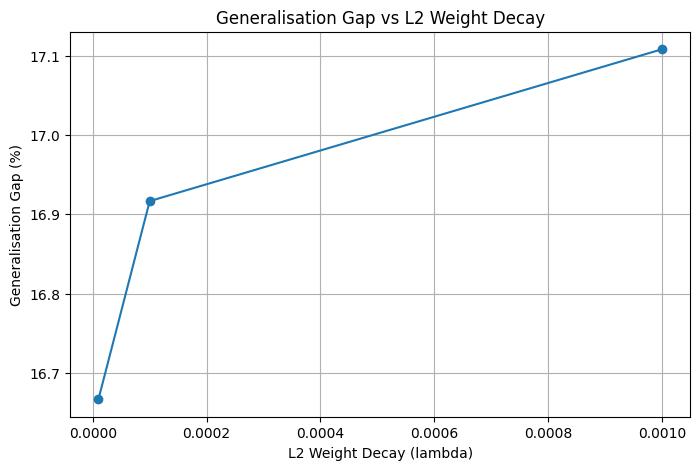

In [96]:
l2_plot = pd.DataFrame(l2_results)

plt.figure(figsize=(8, 5))

plt.plot(
    l2_plot["Setting"],
    l2_plot["Gap"] * 100,
    marker="o"
)

plt.xlabel("L2 Weight Decay (lambda)")
plt.ylabel("Generalisation Gap (%)")
plt.title("Generalisation Gap vs L2 Weight Decay")
plt.grid(True)

plt.show()

### Plot generalisation gap against dropout strength

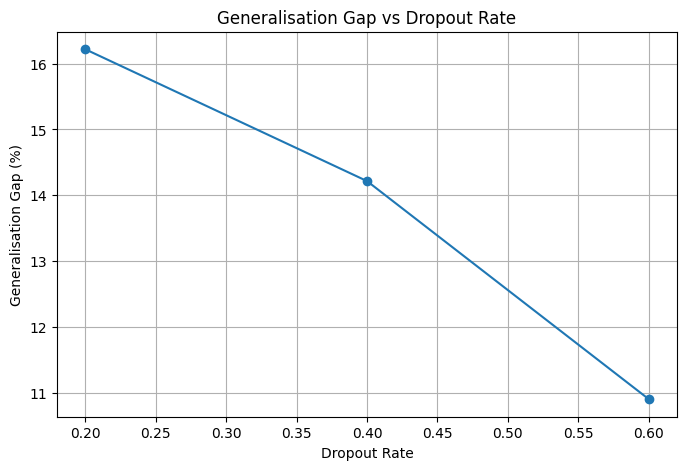

In [97]:
dropout_plot = pd.DataFrame(dropout_results)

plt.figure(figsize=(8, 5))

plt.plot(
    dropout_plot["Setting"],
    dropout_plot["Gap"] * 100,
    marker="o"
)

plt.xlabel("Dropout Rate")
plt.ylabel("Generalisation Gap (%)")
plt.title("Generalisation Gap vs Dropout Rate")
plt.grid(True)

plt.show()

#### identify the best method

In [98]:
best_method = results_df.loc[
    results_df["Gap"].idxmin()
]

print("Method with smallest generalisation gap:")
print(best_method)

Method with smallest generalisation gap:
Method                           Early stopping
Setting                patience = 5, epoch = 15
Train accuracy                             91.0
Validation accuracy                        81.6
Gap                                         9.4
Name: 9, dtype: object


In [99]:
comparison_df = results_df.copy()

comparison_df["Gap reduction"] = (
    results_df["Gap"].iloc[0] -
    comparison_df["Gap"]
)

comparison_df["Training accuracy loss"] = (
    results_df["Train accuracy"].iloc[0] -
    comparison_df["Train accuracy"]
)

comparison_df = comparison_df[
    comparison_df["Method"] !=
    "Baseline (no regularisation)"
]

comparison_df[
    [
        "Method",
        "Setting",
        "Gap reduction",
        "Training accuracy loss"
    ]
].sort_values(
    by="Gap reduction",
    ascending=False
)

,Method,Setting,Gap reduction,Training accuracy loss
9,Early stopping,"patience = 5, epoch = 15",7.533333,9.00
7,Dropout,0.6,6.025000,5.95
12,More training data,"20,000 samples",5.080000,0.73
11,More training data,"10,000 samples",4.740000,3.19
10,Data augmentation,Flip + rotation 10°,3.258333,3.85
6,Dropout,0.4,2.716667,1.95
5,Dropout,0.2,0.716667,0.80
4,L1 penalty,0.00001,0.291667,0.00
1,L2 weight decay,0.00001,0.266667,0.00
2,L2 weight decay,0.0001,0.016667,0.00


## PART 6 - [Results]

### Gap reduction vs. training accuracy cost (relative to baseline)

| Method | Setting | Gap Reduction (pp) | Training Accuracy Loss (pp) |
|---|---|---:|---:|
| Early stopping | patience = 5, epoch = 15 | 7.53 | 9.00 |
| Dropout | 0.6 | 6.03 | 5.95 |
| More training data | 20,000 samples | 5.08 | 0.73 |
| More training data | 10,000 samples | 4.74 | 3.19 |
| Data augmentation | Flip + rotation 10° | 3.26 | 3.85 |
| Dropout | 0.4 | 2.72 | 1.95 |
| Dropout | 0.2 | 0.72 | 0.80 |
| L1 penalty | 0.00001 | 0.29 | 0.00 |
| L2 weight decay | 0.00001 | 0.27 | 0.00 |
| L2 weight decay | 0.0001 | 0.02 | 0.00 |
| Batch normalisation | - | -0.15 | 0.00 |
| L2 weight decay | 0.001 | -0.18 | 0.00 |

Early stopping produced the largest generalisation-gap reduction (7.53 percentage points), but it came at the highest cost in training accuracy (a 9.00-point drop), showing that it closes the gap partly by cutting training short rather than by genuinely improving generalisation. Dropout at rate 0.6 gave the second-largest gap reduction, but similarly sacrificed nearly 6 points of training accuracy. By contrast, training on 20,000 samples achieved almost as large a gap reduction (5.08 points) while costing only 0.73 points of training accuracy the best trade-off of all methods tested, since it tackles the root cause of overfitting (too little data for the model's capacity) instead of penalizing the model after the fact. Weaker L1/L2 settings and batch normalisation barely moved the gap, and the strongest L2 setting (0.001) and batch normalisation actually made the gap slightly worse than baseline in this run, indicating those settings were not well matched to this architecture and data size.

## PART 7 - Hyperparameter Tuning with k-Fold Cross-Validation

### Imports and search space 

In [100]:
from sklearn.model_selection import KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import random
import copy
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [101]:
# Search space: 3 hyperparameters

learning_rates = [0.0001, 0.0005, 0.001, 0.005]
hidden_widths = [256, 512, 768]
dropout_rates = [0.2, 0.4, 0.6]

search_space = {
    "learning_rate": learning_rates,
    "hidden_width": hidden_widths,
    "dropout": dropout_rates
}

print("Search space:")
print(search_space)

Search space:
{'learning_rate': [0.0001, 0.0005, 0.001, 0.005], 'hidden_width': [256, 512, 768], 'dropout': [0.2, 0.4, 0.6]}


### Generate 12 Random Configurations

In [102]:
random.seed(42)

all_configurations = [
    (lr, width, dropout)
    for lr in learning_rates
    for width in hidden_widths
    for dropout in dropout_rates
]

random.shuffle(all_configurations)

configurations = all_configurations[:12]

for i, config in enumerate(configurations, 1):
    print(
        f"{i:2d}: learning_rate={config[0]}, "
        f"hidden_width={config[1]}, "
        f"dropout={config[2]}"
    )

 1: learning_rate=0.0005, hidden_width=256, dropout=0.2
 2: learning_rate=0.0005, hidden_width=512, dropout=0.2
 3: learning_rate=0.0001, hidden_width=512, dropout=0.6
 4: learning_rate=0.005, hidden_width=256, dropout=0.2
 5: learning_rate=0.005, hidden_width=512, dropout=0.6
 6: learning_rate=0.001, hidden_width=256, dropout=0.4
 7: learning_rate=0.005, hidden_width=512, dropout=0.2
 8: learning_rate=0.001, hidden_width=768, dropout=0.4
 9: learning_rate=0.001, hidden_width=512, dropout=0.4
10: learning_rate=0.001, hidden_width=768, dropout=0.6
11: learning_rate=0.005, hidden_width=512, dropout=0.4
12: learning_rate=0.0005, hidden_width=256, dropout=0.4


### Model for hyperparameter tuning

In [103]:
class TunedMLP(nn.Module):
    def __init__(self, hidden_width=512, dropout_rate=0.4):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(784, hidden_width),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_width, hidden_width),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_width, hidden_width),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_width, hidden_width),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(hidden_width, 10)
        )

    def forward(self, x):
        return self.network(x)

### Training funtion for 1 fold

In [104]:
def train_one_fold(
    X_train_fold,
    y_train_fold,
    X_val_fold,
    y_val_fold,
    learning_rate,
    hidden_width,
    dropout_rate,
    epochs=20
):
    train_dataset = TensorDataset(
        torch.tensor(X_train_fold, dtype=torch.float32),
        torch.tensor(y_train_fold, dtype=torch.long)
    )

    val_dataset = TensorDataset(
        torch.tensor(X_val_fold, dtype=torch.float32),
        torch.tensor(y_val_fold, dtype=torch.long)
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=128,
        shuffle=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=128,
        shuffle=False
    )

    model = TunedMLP(
        hidden_width=hidden_width,
        dropout_rate=dropout_rate
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=0.001
    )

    for epoch in range(epochs):
        model.train()

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            predictions = outputs.argmax(dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total

    return accuracy

### 5-fold cross validation

In [105]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for config_number, (lr, width, dropout) in enumerate(configurations, 1):

    fold_scores = []

    print(
        f"\nConfiguration {config_number}/12: "
        f"lr={lr}, width={width}, dropout={dropout}"
    )

    for fold, (train_idx, val_idx) in enumerate(
        kf.split(X_train), 1
    ):

        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]

        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]

        score = train_one_fold(
            X_fold_train,
            y_fold_train,
            X_fold_val,
            y_fold_val,
            learning_rate=lr,
            hidden_width=width,
            dropout_rate=dropout,
            epochs=20
        )

        fold_scores.append(score)

        print(
            f"  Fold {fold}: "
            f"{score * 100:.2f}%"
        )

    mean_score = np.mean(fold_scores)
    std_score = np.std(fold_scores)

    cv_results.append({
        "Configuration": config_number,
        "Learning rate": lr,
        "Hidden width": width,
        "Dropout": dropout,
        "Mean CV accuracy": mean_score,
        "Std CV accuracy": std_score
    })

    print(
        f"  Mean: {mean_score * 100:.2f}% | "
        f"Std: {std_score * 100:.2f}%"
    )


Configuration 1/12: lr=0.0005, width=256, dropout=0.2
  Fold 1: 88.31%
  Fold 2: 88.43%
  Fold 3: 87.96%
  Fold 4: 88.98%
  Fold 5: 87.60%
  Mean: 88.26% | Std: 0.46%

Configuration 2/12: lr=0.0005, width=512, dropout=0.2
  Fold 1: 87.71%
  Fold 2: 86.55%
  Fold 3: 88.20%
  Fold 4: 88.76%
  Fold 5: 87.90%
  Mean: 87.82% | Std: 0.73%

Configuration 3/12: lr=0.0001, width=512, dropout=0.6
  Fold 1: 87.32%
  Fold 2: 87.24%
  Fold 3: 88.23%
  Fold 4: 88.03%
  Fold 5: 87.47%
  Mean: 87.66% | Std: 0.40%

Configuration 4/12: lr=0.005, width=256, dropout=0.2
  Fold 1: 84.89%
  Fold 2: 84.16%
  Fold 3: 84.25%
  Fold 4: 84.07%
  Fold 5: 84.70%
  Mean: 84.41% | Std: 0.32%

Configuration 5/12: lr=0.005, width=512, dropout=0.6
  Fold 1: 69.55%
  Fold 2: 72.00%
  Fold 3: 71.26%
  Fold 4: 64.67%
  Fold 5: 67.61%
  Mean: 69.02% | Std: 2.65%

Configuration 6/12: lr=0.001, width=256, dropout=0.4
  Fold 1: 87.09%
  Fold 2: 86.95%
  Fold 3: 86.61%
  Fold 4: 87.69%
  Fold 5: 86.81%
  Mean: 87.03% | Std: 0

### Reporting the top 5 configurations

In [106]:
cv_results_df = pd.DataFrame(cv_results)

cv_results_df = cv_results_df.sort_values(
    "Mean CV accuracy",
    ascending=False
).reset_index(drop=True)

print("Top 5 configurations:")

top_5 = cv_results_df.head(5).copy()

top_5["Mean CV accuracy"] *= 100
top_5["Std CV accuracy"] *= 100

top_5

Top 5 configurations:


,Configuration,Learning rate,Hidden width,Dropout,Mean CV accuracy,Std CV accuracy
0,1,0.0005,256,0.2,88.256250,0.462369
1,2,0.0005,512,0.2,87.822917,0.728422
2,12,0.0005,256,0.4,87.681250,0.459874
3,3,0.0001,512,0.6,87.658333,0.397169
4,8,0.0010,768,0.4,87.168750,0.181549


### Select the best configuraion

In [107]:
best_config = cv_results_df.iloc[0]

best_learning_rate = best_config["Learning rate"]
best_hidden_width = int(best_config["Hidden width"])
best_dropout = best_config["Dropout"]

print("Selected configuration:")
print("Learning rate:", best_learning_rate)
print("Hidden width:", best_hidden_width)
print("Dropout:", best_dropout)
print("Mean CV accuracy:", best_config["Mean CV accuracy"] * 100)

Selected configuration:
Learning rate: 0.0005
Hidden width: 256
Dropout: 0.2
Mean CV accuracy: 88.25625000000001


### Retrain on the full 48,000 sample training set

In [108]:
full_train_dataset = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.long)
)

full_train_loader = DataLoader(
    full_train_dataset,
    batch_size=128,
    shuffle=True
)

final_model = TunedMLP(
    hidden_width=best_hidden_width,
    dropout_rate=best_dropout
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=best_learning_rate,
    weight_decay=0.001
)

final_epochs = 20

for epoch in range(final_epochs):

    final_model.train()

    running_loss = 0.0

    for X_batch, y_batch in full_train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()

        outputs = final_model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(
        f"Epoch {epoch + 1:2d}/{final_epochs} "
        f"- Loss: {running_loss / len(full_train_loader):.4f}"
    )

Epoch  1/20 - Loss: 0.8197
Epoch  2/20 - Loss: 0.4808
Epoch  3/20 - Loss: 0.4286
Epoch  4/20 - Loss: 0.4010
Epoch  5/20 - Loss: 0.3841
Epoch  6/20 - Loss: 0.3707
Epoch  7/20 - Loss: 0.3610
Epoch  8/20 - Loss: 0.3501
Epoch  9/20 - Loss: 0.3474
Epoch 10/20 - Loss: 0.3383
Epoch 11/20 - Loss: 0.3346
Epoch 12/20 - Loss: 0.3262
Epoch 13/20 - Loss: 0.3245
Epoch 14/20 - Loss: 0.3215
Epoch 15/20 - Loss: 0.3140
Epoch 16/20 - Loss: 0.3132
Epoch 17/20 - Loss: 0.3100
Epoch 18/20 - Loss: 0.3047
Epoch 19/20 - Loss: 0.3015
Epoch 20/20 - Loss: 0.2971


### Evaluate once on the held-out test set

In [109]:
test_dataset = TensorDataset(
    torch.tensor(X_test, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.long)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

final_model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        outputs = final_model(X_batch)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            y_batch.cpu().numpy()
        )

test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

test_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

print(f"Test accuracy:  {test_accuracy * 100:.2f}%")
print(f"Macro precision: {test_precision * 100:.2f}%")
print(f"Macro recall:    {test_recall * 100:.2f}%")
print(f"Macro F1:        {test_f1 * 100:.2f}%")

Test accuracy:  88.36%
Macro precision: 88.81%
Macro recall:    88.36%
Macro F1:        88.44%


### Confusion matrix

Confusion Matrix:
[[785   2   5  21   0   1 182   0   4   0]
 [  1 984   0  10   2   0   3   0   0   0]
 [ 14   0 737  11 142   0  95   0   1   0]
 [ 18  12   5 888  42   0  35   0   0   0]
 [  0   0  43  20 883   0  53   0   1   0]
 [  0   0   0   0   0 939   0  36   4  21]
 [ 95   2  54  19  73   0 751   0   6   0]
 [  0   0   0   0   0  15   0 950   0  35]
 [  5   0   3   1   4   4  12   2 969   0]
 [  0   0   0   0   0   5   0  45   0 950]]


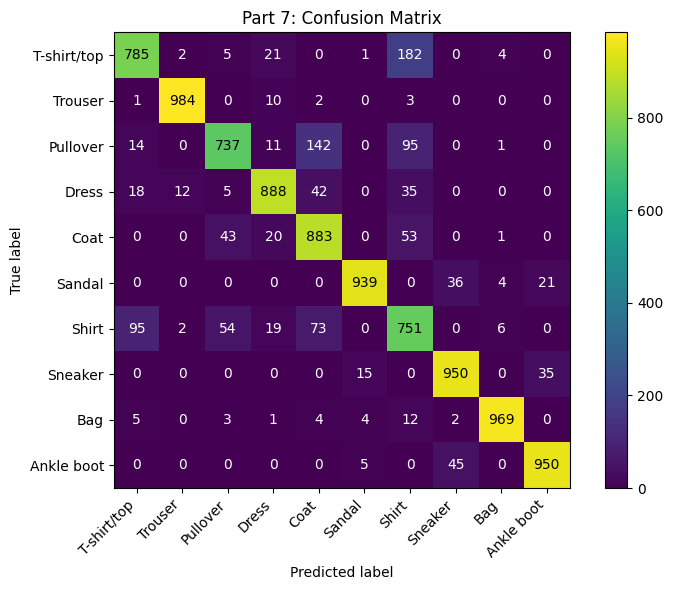

In [2]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)


print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Part 7: Confusion Matrix")

plt.xticks(
    range(10),
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(10),
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] < cm.max() / 2 else "black"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

### Compare with actual part 2 baseline

In [111]:
part2_baseline_accuracy = 0.8819

improvement_pp = (
    test_accuracy - part2_baseline_accuracy
) * 100

print(
    f"Part 2 baseline accuracy: "
    f"{part2_baseline_accuracy * 100:.2f}%"
)

print(
    f"Part 7 test accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Improvement: "
    f"{improvement_pp:+.2f} percentage points"
)

if improvement_pp > 0:
    print("The tuned model improved over the Part 2 baseline.")
elif improvement_pp < 0:
    print("The tuned model did not improve over the Part 2 baseline.")
else:
    print("The tuned model matched the Part 2 baseline.")

Part 2 baseline accuracy: 88.19%
Part 7 test accuracy: 88.36%
Improvement: +0.17 percentage points
The tuned model improved over the Part 2 baseline.


### Final Report

In [112]:
print("Search space:")
print("Learning rate:", learning_rates)
print("Hidden width:", hidden_widths)
print("Dropout rate:", dropout_rates)

print("\nTop 5 configurations:")
display(top_5)

print("\nSelected configuration:")
print(best_config)

print("\nFinal test results:")
print(f"Accuracy:         {test_accuracy * 100:.2f}%")
print(f"Macro precision:  {test_precision * 100:.2f}%")
print(f"Macro recall:     {test_recall * 100:.2f}%")
print(f"Macro F1:         {test_f1 * 100:.2f}%")
print(f"Improvement:      {improvement_pp:+.2f} percentage points")

Search space:
Learning rate: [0.0001, 0.0005, 0.001, 0.005]
Hidden width: [256, 512, 768]
Dropout rate: [0.2, 0.4, 0.6]

Top 5 configurations:


,Configuration,Learning rate,Hidden width,Dropout,Mean CV accuracy,Std CV accuracy
0,1,0.0005,256,0.2,88.256250,0.462369
1,2,0.0005,512,0.2,87.822917,0.728422
2,12,0.0005,256,0.4,87.681250,0.459874
3,3,0.0001,512,0.6,87.658333,0.397169
4,8,0.0010,768,0.4,87.168750,0.181549



Selected configuration:
Configuration         1.000000
Learning rate         0.000500
Hidden width        256.000000
Dropout               0.200000
Mean CV accuracy      0.882563
Std CV accuracy       0.004624
Name: 0, dtype: float64

Final test results:
Accuracy:         88.36%
Macro precision:  88.81%
Macro recall:     88.36%
Macro F1:         88.44%
Improvement:      +0.17 percentage points


## PART 7 - [Results]

### Search space

| Hyperparameter | Values Searched |
|---|---|
| Learning rate | 0.0001, 0.0005, 0.001, 0.005 |
| Hidden width | 256, 512, 768 |
| Dropout rate | 0.2, 0.4, 0.6 |

### Top 5 configurations

| Rank | Learning Rate | Hidden Width | Dropout | Mean CV Accuracy | Std |
|---|---|---|---|---:|---:|
| 1 | 0.0005 | 256 | 0.2 | 88.26% | 0.46% |
| 2 | 0.0005 | 512 | 0.2 | 87.82% | 0.73% |
| 3 | 0.0005 | 256 | 0.4 | 87.68% | 0.46% |
| 4 | 0.0001 | 512 | 0.6 | 87.66% | 0.40% |
| 5 | 0.0010 | 768 | 0.4 | 87.17% | 0.18% |

### Selected configuration

| Hyperparameter | Value |
|---|---:|
| Learning rate | 0.0005 |
| Hidden width | 256 |
| Dropout | 0.2 |
| Mean CV accuracy | 88.26% |
| Std CV accuracy | 0.46% |

### Final test results

| Metric | Value |
|---|---:|
| Accuracy | 88.36% |
| Macro precision | 88.81% |
| Macro recall | 88.36% |
| Macro F1 | 88.44% |
| Improvement over Part 2 baseline | +0.17 pp |

The 5-fold cross-validated random search selected learning rate = 0.0005, hidden width = 256, dropout = 0.2 as the best configuration, with a mean CV accuracy of 88.26% (± 0.46%). Notably, the smallest hidden width tested (256) outperformed the larger 512- and 768-unit configurations, suggesting that with only 12 random configurations and 5-fold CV, a smaller, better-regularised network generalised more reliably than larger ones on this dataset. Retrained on the full 48,000-sample training set and evaluated once on the held-out test set, this configuration reached 88.36% test accuracy, a modest +0.17 percentage-point improvement over the Part 2 ReLU baseline (88.19%). The small magnitude of this improvement suggests the search space and budget (12 configurations) may already be close to the performance ceiling for this architecture family on Fashion-MNIST, with further gains likely requiring larger search budgets, different architectures, or additional data rather than further hyperparameter tuning alone.